In [1]:
# ── FULL RESTORE + REBUILD FOR VISUALIZATION ──────────────────────────────────
import torch, random, numpy as np, sys, os, math, re
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import BertModel, BertTokenizer

# Constants
MAX_TURNS   = 6
MAX_TOK_LEN = 40
D_DEC       = 512
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base        = '/content/Discourse-Mutual-Information-DMI-main/data/dailydialog'
ckpt_dir    = '/content/drive/MyDrive/data/dmi_checkpoints'

In [2]:
# 1. Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Create the output folder
import os
os.makedirs('/content/drive/MyDrive/data/dmi_checkpoints', exist_ok=True)

Mounted at /content/drive


In [3]:
!ls /content/drive/MyDrive/data/dmi_checkpoints/

 ablation_train_dmi.pt	       DMI_medium_model.pth
 ablation_valid_dmi.pt	      'model_best_auc[22F3A0D8].pth'
 decoder_ablation_DMI.pth     'model_best_auc[7437A912].pth'
 decoder_ablation_PLAIN.pth   'model_current[22F3A0D8].pth'
 decoder_ablation_RANDOM.pth


In [ ]:
import os, glob

ckpt_dir = '/content/drive/MyDrive/data/dmi_checkpoints'
files = glob.glob(f'{ckpt_dir}/*.pth')

# Sort by modification time, newest first
files.sort(key=os.path.getmtime, reverse=True)
for f in files:
    mtime = os.path.getmtime(f)
    import datetime
    print(f"{datetime.datetime.fromtimestamp(mtime).strftime('%Y-%m-%d %H:%M:%S')}  {os.path.basename(f)}")

In [ ]:
# Fix tokenizers by installing a pre-built compatible version first
!pip install tokenizers==0.10.3 --find-links https://github.com/huggingface/tokenizers/releases/tag/v0.10.3 || \
 pip install tokenizers==0.13.3  # fallback: newer tokenizers, still compatible

# Install the rest (let pip resolve tokenizers version)
!pip install "transformers==4.8.2" datasets wandb tqdm --no-build-isolation

# Step 1: install tokenizers binary-only (no source build) first
!pip install tokenizers --only-binary=:all:

# Step 2: install transformers without re-triggering the tokenizers conflict
!pip install "transformers>=4.20,<5.0" datasets wandb tqdm

Looking in links: https://github.com/huggingface/tokenizers/releases/tag/v0.10.3
  Using cached tokenizers-0.10.3.tar.gz (212 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)
  Using cached tokenizers-0.13.3.tar.gz (314 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ ex

In [4]:
# Unzip repo if needed
if not os.path.exists('/content/Discourse-Mutual-Information-DMI-main'):
    os.system('unzip -q /content/drive/MyDrive/Discourse-Mutual-Information-DMI-main.zip -d /content/')
sys.path.insert(0, '/content/Discourse-Mutual-Information-DMI-main')

In [ ]:
%cd /content/Discourse-Mutual-Information-DMI-main

!python pretrain.py \
  -dd dd \
  -voc roberta \
  -sym \
  -bs 32 \
  -ep 200 \
  -vi 100 \
  -li 20 \
  -lr 5e-5 \
  -scdl \
  --data_path ./data \
  -op /content/drive/MyDrive/data/dmi_checkpoints \
  -t 0 \
  -ntq \
  -ws 1
  # ⚠️ NO --roberta_init flag = from scratch ✓
  # ⚠️ NO -ddp flag = single GPU mode ✓


/content/Discourse-Mutual-Information-DMI-main
1779195467.019778
b'1779195467.019778'
*** RUN ID: [E9723976] ***
ARGUMENTS:
-----------
	-- dataset: dd
	-- reddit_filter_enabled: False
	-- rmax_path: None
	-- data_path: ./data
	-- output_path: /content/drive/MyDrive/data/dmi_checkpoints
	-- vocab: roberta
	-- roberta_init: False
	-- roberta_name: roberta-base
	-- d_model: 512
	-- dim_feedforward: 2048
	-- projection: 512
	-- encoder_layers: 4
	-- encoder_heads: 4
	-- symmetric_loss: True
	-- unsupervised_discourse_losses: False
	-- supervised_discourse_losses: False
	-- estimator: infonce
	-- batch_size: 32
	-- epochs: 200
	-- val_interval: 100
	-- log_interval: 20
	-- learning_rate: 5e-05
	-- learning_rate_control: False
	-- tracking: 0
	-- use_scheduler: True
	-- no_tqdm: True
	-- distdp: False
	-- world_size: 1
	-- resume: False
	-- resume_model_path: None
	-- UNIQ_RUN_ID: E9723976


Vocab Size: 50265
File: ./data/dailydialog/dialogues_train.txt
Loading data: 11118it [00:00, 82117.0

In [ ]:
# No download needed — data is already in the repo
!ls /content/drive/MyDrive/Discourse-Mutual-Information-DMI-main/data/dailydialog/
# dialogues_test.txt  dialogues_train.txt  dialogues_valid.txt

dialogues_test.txt  dialogues_train.txt  dialogues_valid.txt


In [ ]:
# Find and patch the torch.load line in pretrain.py
!sed -i 's/torch.load(args.resume_model_path, map_location=device)/torch.load(args.resume_model_path, map_location=device, weights_only=False)/' \
  /content/Discourse-Mutual-Information-DMI-main/pretrain.py

# Verify the change was applied
!grep -n "torch.load" /content/Discourse-Mutual-Information-DMI-main/pretrain.py

474:        checkpoint = torch.load(args.resume_model_path, map_location=device, weights_only=False)


In [ ]:
# resume from saved checkpoint

%cd /content/Discourse-Mutual-Information-DMI-main

!python pretrain.py \
  -dd dd \
  -voc roberta \
  -sym \
  -bs 32 \
  -ep 200 \
  -vi 100 \
  -li 20 \
  -lr 5e-5 \
  -scdl \
  --data_path ./data \
  -op /content/drive/MyDrive/data/dmi_checkpoints \
  -t 0 \
  -ntq \
  --resume \
  --resume_model_path "/content/drive/MyDrive/data/dmi_checkpoints/model_current[22F3A0D8].pth"

/content/Discourse-Mutual-Information-DMI-main
2026-05-14 20:59:03.457257: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
1778792348.134135
b'1778792348.134135'
*** RUN ID: [FE1F5CF1] ***
ARGUMENTS:
-----------
	-- dataset: dd
	-- reddit_filter_enabled: False
	-- rmax_path: None
	-- data_path: ./data
	-- output_path: /content/drive/MyDrive/data/dmi_checkpoints
	-- vocab: roberta
	-- roberta_init: False
	-- roberta_name: roberta-base
	-- d_model: 512
	-- dim_feedforward: 2048
	-- projection: 512
	-- encoder_layers: 4
	-- encoder_heads: 4
	-- symmetric_loss: True
	-- unsupervised_discourse_losses: False
	-- supervised_discourse_losses: False
	-- estimator: infonce
	-- batch_size: 32
	-- epochs: 200
	-- val_interval: 100
	-- log_interval: 20
	-- le

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import sys
sys.path.insert(0, '/content/Discourse-Mutual-Information-DMI-main')

from models.core import SMI
from transformers import RobertaTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt = torch.load(
    '/content/drive/MyDrive/data/dmi_checkpoints/model_best_auc[22F3A0D8].pth',
    map_location=device,
    weights_only=False
)

args = ckpt['args']

model = SMI(
    vocab_size=50265,
    d_model=args['d_model'],
    projection_size=args['projection'],
    encoder_layers=args['encoder_layers'],
    encoder_heads=args['encoder_heads'],
    symmetric_loss=args['symmetric_loss'],
    roberta_init=args['roberta_init']
).to(device)

state_dict = {k.replace('module.', ''): v
              for k, v in ckpt['model_state_dict'].items()}

model.load_state_dict(state_dict)
model.eval()
print("DMI loaded! AUC at save:", ckpt['auc'])

ModuleNotFoundError: No module named 'models'

In [ ]:
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

def encode_context(utterances, max_len=128):
    text = ' </s> '.join(utterances)
    tokens = tokenizer(text, return_tensors='pt',
                       max_length=max_len, truncation=True,
                       padding='max_length')
    input_ids = tokens['input_ids'].to(device)
    with torch.no_grad():
        emb = model.embedding(input_ids)
        out = model.encoder(emb, None)
        c_t = out[:, 0, :]
    return c_t.squeeze().cpu().numpy()

def load_data(dialog_file, act_file):
    dialogs = open(dialog_file).readlines()
    acts    = open(act_file).readlines()
    contexts, labels = [], []
    for dialog, act_line in zip(dialogs, acts):
        utterances = [u.strip() for u in dialog.strip().split('__eou__') if u.strip()]
        act_labels = [int(a) - 1 for a in act_line.strip().split()]
        for i in range(1, len(utterances)):
            contexts.append(utterances[:i])
            labels.append(act_labels[i])
    return contexts, labels

base = '/content/Discourse-Mutual-Information-DMI-main/data/dailydialog'
train_ctx, train_lbl = load_data(f'{base}/dialogues_train.txt',      f'{base}/dialogues_act.txt')
valid_ctx, valid_lbl = load_data(f'{base}/dialogues_validation.txt',  f'{base}/dialogues_act_validation.txt')

print(f"Train: {len(train_ctx)} samples, Valid: {len(valid_ctx)} samples")
print(f"Label distribution train: {np.bincount(train_lbl)}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Discourse-Mutual-Information-DMI-main/data/dailydialog/dialogues_act.txt'

In [ ]:
from transformers import BertModel, BertTokenizer
import torch.nn as nn

# Build the encoder directly from HuggingFace
bert = BertModel.from_pretrained('google/bert_uncased_L-8_H-768_A-12',
                                  add_pooling_layer=False).to(device)

# Load only the encoder weights from the checkpoint
encoder_state = {k.replace('encoder.', '', 1): v
                 for k, v in state_dict.items()
                 if k.startswith('encoder.')}
bert.load_state_dict(encoder_state, strict=False)
bert.eval()
print("Loaded! Unexpected keys are harmless position_ids buffer.")

# Load the projection head
proj_weight = state_dict['proj.W.weight']
proj_bias   = state_dict['proj.W.bias']
proj = nn.Linear(768, 768).to(device)
proj.weight = nn.Parameter(proj_weight)
proj.bias   = nn.Parameter(proj_bias)

print("Authors model loaded manually!")
print("Encoder params:", sum(p.numel() for p in bert.parameters()))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/327M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/bert_uncased_L-8_H-768_A-12
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
bert.pooler.dense.weight                   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
bert.pooler.dense.bias                     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NameError: name 'device' is not defined

In [ ]:
# ── Re-load data (run this if train_ctx is not defined) ──────────────────
import numpy as np
import sys
sys.path.insert(0, '/content/Discourse-Mutual-Information-DMI-main')

def load_data(dialog_file, act_file):
    dialogs = open(dialog_file).readlines()
    acts    = open(act_file).readlines()
    contexts, labels = [], []
    for dialog, act_line in zip(dialogs, acts):
        utterances = [u.strip() for u in dialog.strip().split('__eou__') if u.strip()]
        act_labels = [int(a) - 1 for a in act_line.strip().split()]
        for i in range(1, len(utterances)):
            contexts.append(utterances[:i])
            labels.append(act_labels[i])
    return contexts, labels

base = '/content/Discourse-Mutual-Information-DMI-main/data/dailydialog'
train_ctx, train_lbl = load_data(f'{base}/dialogues_train.txt',
                                  f'{base}/dialogues_act.txt')
valid_ctx, valid_lbl = load_data(f'{base}/dialogues_validation.txt',
                                  f'{base}/dialogues_act_validation.txt')

# aliases expected by the TF-IDF cell
y_train = train_lbl
y_valid  = valid_lbl

print(f"Train: {len(train_ctx)} | Valid: {len(valid_ctx)}")
print(f"Label distribution train: {np.bincount(y_train)}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Discourse-Mutual-Information-DMI-main/data/dailydialog/dialogues_act.txt'

In [ ]:
import re

def tag_act(utterance):
    u = utterance.strip()
    # Question → ends with ? or starts with question word
    if u.endswith('?'):
        return 1  # Question
    # Directive → imperative-like (starts with verb in base form)
    if re.match(r'^(please|could you|can you|would you|let|make|stop|try|go|come|tell|give|take|bring|put|help)', u.lower()):
        return 2  # Directive
    # Commissive → commitment/promise language
    if re.match(r"^(i will|i'll|i can|i could|i would|i'd|we will|we'll|sure|of course|definitely)", u.lower()):
        return 3  # Commissive
    # Default → Inform
    return 0

def load_data_with_tags(dialog_file):
    dialogs = open(dialog_file).readlines()
    contexts, labels = [], []
    for dialog in dialogs:
        utterances = [u.strip() for u in dialog.strip().split('__eou__') if u.strip()]
        for i in range(1, len(utterances)):
            contexts.append(utterances[:i])
            labels.append(tag_act(utterances[i]))
    return contexts, labels

base = '/content/Discourse-Mutual-Information-DMI-main/data/dailydialog'
train_ctx, train_lbl = load_data_with_tags(f'{base}/dialogues_train.txt')
valid_ctx, valid_lbl = load_data_with_tags(f'{base}/dialogues_valid.txt')

import numpy as np
print(f"Train: {len(train_ctx)} samples")
print(f"Label distribution: {np.bincount(train_lbl)}")
print(f"  0=Inform: {np.bincount(train_lbl)[0]}")
print(f"  1=Question: {np.bincount(train_lbl)[1]}")
print(f"  2=Directive: {np.bincount(train_lbl)[2]}")
print(f"  3=Commissive: {np.bincount(train_lbl)[3]}")

Train: 76052 samples
Label distribution: [49599 21881  1845  2727]
  0=Inform: 49599
  1=Question: 21881
  2=Directive: 1845
  3=Commissive: 2727


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Aliases
y_train = train_lbl
y_valid  = valid_lbl

train_texts = [' '.join(ctx) for ctx in train_ctx]
valid_texts  = [' '.join(ctx) for ctx in valid_ctx]

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf_train = tfidf.fit_transform(train_texts)
X_tfidf_valid = tfidf.transform(valid_texts)

probe_tfidf = LogisticRegression(max_iter=1000, C=1.0)
probe_tfidf.fit(X_tfidf_train, y_train)
y_tfidf = probe_tfidf.predict(X_tfidf_valid)

dummy = DummyClassifier(strategy='stratified')
dummy.fit(X_tfidf_train, y_train)
y_dummy = dummy.predict(X_tfidf_valid)

print("=== TF-IDF (surface text) ===")
print(f"Accuracy: {accuracy_score(y_valid, y_tfidf):.4f}")
print(classification_report(y_valid, y_tfidf,
      target_names=['Inform', 'Question', 'Directive', 'Commissive']))

print("=== Random stratified baseline ===")
print(f"Accuracy: {accuracy_score(y_valid, y_dummy):.4f}")

=== TF-IDF (surface text) ===
Accuracy: 0.6309
              precision    recall  f1-score   support

      Inform       0.65      0.93      0.76      4472
    Question       0.45      0.15      0.23      2134
   Directive       0.00      0.00      0.00       212
  Commissive       0.00      0.00      0.00       251

    accuracy                           0.63      7069
   macro avg       0.28      0.27      0.25      7069
weighted avg       0.55      0.63      0.55      7069

=== Random stratified baseline ===
Accuracy: 0.5056


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.dummy import DummyClassifier

# class_weight='balanced' penalizes majority class
probe_tfidf_bal = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced')
probe_tfidf_bal.fit(X_tfidf_train, y_train)
y_tfidf_bal = probe_tfidf_bal.predict(X_tfidf_valid)

dummy_maj = DummyClassifier(strategy='most_frequent')
dummy_maj.fit(X_tfidf_train, y_train)
y_dummy_maj = dummy_maj.predict(X_tfidf_valid)

print("=== TF-IDF balanced ===")
print(f"Accuracy: {accuracy_score(y_valid, y_tfidf_bal):.4f}")
print(classification_report(y_valid, y_tfidf_bal,
      target_names=['Inform', 'Question', 'Directive', 'Commissive'],
      zero_division=0))

print("=== Majority class baseline ===")
print(f"Accuracy: {accuracy_score(y_valid, y_dummy_maj):.4f}")

=== TF-IDF balanced ===
Accuracy: 0.3691
              precision    recall  f1-score   support

      Inform       0.70      0.36      0.48      4472
    Question       0.40      0.39      0.39      2134
   Directive       0.06      0.41      0.11       212
  Commissive       0.07      0.35      0.11       251

    accuracy                           0.37      7069
   macro avg       0.31      0.38      0.27      7069
weighted avg       0.57      0.37      0.43      7069

=== Majority class baseline ===
Accuracy: 0.6326


In [ ]:
# Hard negatives: sample responses from dialogs with similar topics
# Simple approximation: pick negatives that share at least 1 content word with context

from collections import Counter
import re

def content_words(text):
    stopwords = {'i','you','he','she','it','we','they','the','a','an',
                 'is','are','was','were','do','did','have','has','to',
                 'and','or','but','in','on','at','of','for','with','that'}
    return set(re.findall(r'\b\w+\b', text.lower())) - stopwords

hits_dmi_hard   = 0
hits_tfidf_hard = 0
random.seed(42)

for i in range(len(ctx_tfidf)):
    ctx_words = content_words(' '.join(contexts[i]))

    # Find negatives that share content words (lexically similar but wrong)
    hard_pool = [j for j in range(len(responses))
                 if j != i and len(content_words(responses[j]) & ctx_words) > 0]

    if len(hard_pool) < 9:
        continue  # skip if not enough hard negatives

    neg_idx = random.sample(hard_pool, 9)
    candidates = [i] + neg_idx

    # DMI
    scores_dmi = [ctx_embs[i] @ resp_embs[j] for j in candidates]
    if np.argmax(scores_dmi) == 0:
        hits_dmi_hard += 1

    # TF-IDF
    scores_tfidf = cosine_similarity(ctx_tfidf[i].reshape(1,-1),
                                     resp_tfidf[candidates])[0]
    if np.argmax(scores_tfidf) == 0:
        hits_tfidf_hard += 1

n = len([i for i in range(len(ctx_tfidf))
         if len([j for j in range(len(responses))
                 if j != i and len(content_words(responses[j]) &
                 content_words(' '.join(contexts[i]))) > 0]) >= 9])

print("=== Hard negatives (lexically similar wrong responses) ===")
print(f"TF-IDF cosine:      {hits_tfidf_hard/n:.4f}")
print(f"DMI full context:   {hits_dmi_hard/n:.4f}")
print(f"(evaluated on {n} samples with enough hard negatives)")

=== Hard negatives (lexically similar wrong responses) ===
TF-IDF cosine:      0.3696
DMI full context:   0.2316
(evaluated on 993 samples with enough hard negatives)


plot

In [ ]:
# ── FULL RESTORE + REBUILD FOR VISUALIZATION ──────────────────────────────────
import torch, random, numpy as np, sys, os, math, re
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import BertModel, BertTokenizer

# Constants
MAX_TURNS   = 6
MAX_TOK_LEN = 40
D_DEC       = 512
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base        = '/content/Discourse-Mutual-Information-DMI-main/data/dailydialog'
ckpt_dir    = '/content/drive/MyDrive/data/dmi_checkpoints'

# Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# Unzip repo if needed
if not os.path.exists('/content/Discourse-Mutual-Information-DMI-main'):
    os.system('unzip -q /content/drive/MyDrive/Discourse-Mutual-Information-DMI-main.zip -d /content/')
sys.path.insert(0, '/content/Discourse-Mutual-Information-DMI-main')

# Load DMI medium encoder
print("Loading DMI medium encoder...")
ckpt_med   = torch.load(f'{ckpt_dir}/model_current[22F3A0D8].pth',
                        map_location=device, weights_only=False)
state_dict = {k.replace('module.', ''): v
              for k, v in ckpt_med['model_state_dict'].items()}
bert_med   = BertModel.from_pretrained(
    'google/bert_uncased_L-8_H-768_A-12',
    add_pooling_layer=False).to(device)
encoder_state = {k.replace('encoder.', '', 1): v
                 for k, v in state_dict.items()
                 if k.startswith('encoder.')}
bert_med.load_state_dict(encoder_state, strict=False)
bert_med.eval()
tokenizer_med = BertTokenizer.from_pretrained('google/bert_uncased_L-8_H-768_A-12')
VOCAB_SIZE    = tokenizer_med.vocab_size
print(f"DMI encoder loaded — AUC: {ckpt_med['auc']:.4f}")

# Encode helpers
def encode_single(text, max_len=64):
    tokens = tokenizer_med(text, return_tensors='pt',
                           max_length=max_len, truncation=True,
                           padding='max_length')
    with torch.no_grad():
        out = bert_med(input_ids=tokens['input_ids'].to(device),
                       attention_mask=tokens['attention_mask'].to(device))
    return out.last_hidden_state[:, 0, :].squeeze().cpu()

def encode_context(utterances, max_len=128):
    text   = ' [SEP] '.join(utterances)
    tokens = tokenizer_med(text, return_tensors='pt',
                           max_length=max_len, truncation=True,
                           padding='max_length')
    with torch.no_grad():
        out = bert_med(input_ids=tokens['input_ids'].to(device),
                       attention_mask=tokens['attention_mask'].to(device))
    return out.last_hidden_state[:, 0, :].squeeze().cpu()

# Label functions
def get_discourse_act(utt):
    u = utt.strip()
    if u.endswith('?'): return 1
    if re.match(r'^(please|could you|can you|would you|let|make|stop|try|go|come|tell|give)', u.lower()): return 2
    if re.match(r"^(i will|i'll|i can|i would|i'd|sure|of course|definitely)", u.lower()): return 3
    return 0

def get_dialogue_phase(pos, total):
    if pos / total < 0.25: return 0
    if pos / total > 0.75: return 2
    return 1

def get_topic_domain(utterances):
    text    = ' '.join(utterances).lower()
    domains = {
        0: ['money','pay','salary','bank','price','cost','dollar','yuan','account'],
        1: ['go','street','bus','train','station','direction','turn','left','right'],
        2: ['work','job','company','position','experience','interview','duty'],
        3: ['feel','sick','doctor','hospital','medicine','pain','health'],
        4: ['eat','food','restaurant','menu','dish','delicious','cook'],
    }
    scores = {k: sum(w in text for w in v) for k, v in domains.items()}
    best   = max(scores, key=scores.get)
    return best if scores[best] > 0 else -1

# Build embedding dataset
print("Encoding utterances for visualization...")
random.seed(42)
dialogs = open(f'{base}/dialogues_valid.txt').readlines()
sample  = random.sample(dialogs, 800)

embs, acts, phases, domains, roles = [], [], [], [], []

for dialog in tqdm(sample):
    utts = [u.strip() for u in dialog.strip().split('__eou__') if u.strip()]
    if len(utts) < 3: continue
    utts   = utts[:MAX_TURNS]
    domain = get_topic_domain(utts)
    if domain == -1: continue
    for pos, utt in enumerate(utts):
        embs.append(encode_single(utt).numpy())
        acts.append(get_discourse_act(utt))
        phases.append(get_dialogue_phase(pos, len(utts)))
        domains.append(domain)
        roles.append(pos % 2)

X = np.array(embs)
print(f"Encoded {len(X)} utterances")

# UMAP
!pip install umap-learn -q
import umap
print("Running UMAP...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1,
                    n_components=2, random_state=42, metric='cosine')
X_2d = reducer.fit_transform(X)
print("Done!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading DMI medium encoder...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/327M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/327M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

DMI encoder loaded — AUC: 0.8365
Encoding utterances for visualization...


  0%|          | 0/800 [00:00<?, ?it/s]

KeyboardInterrupt: 

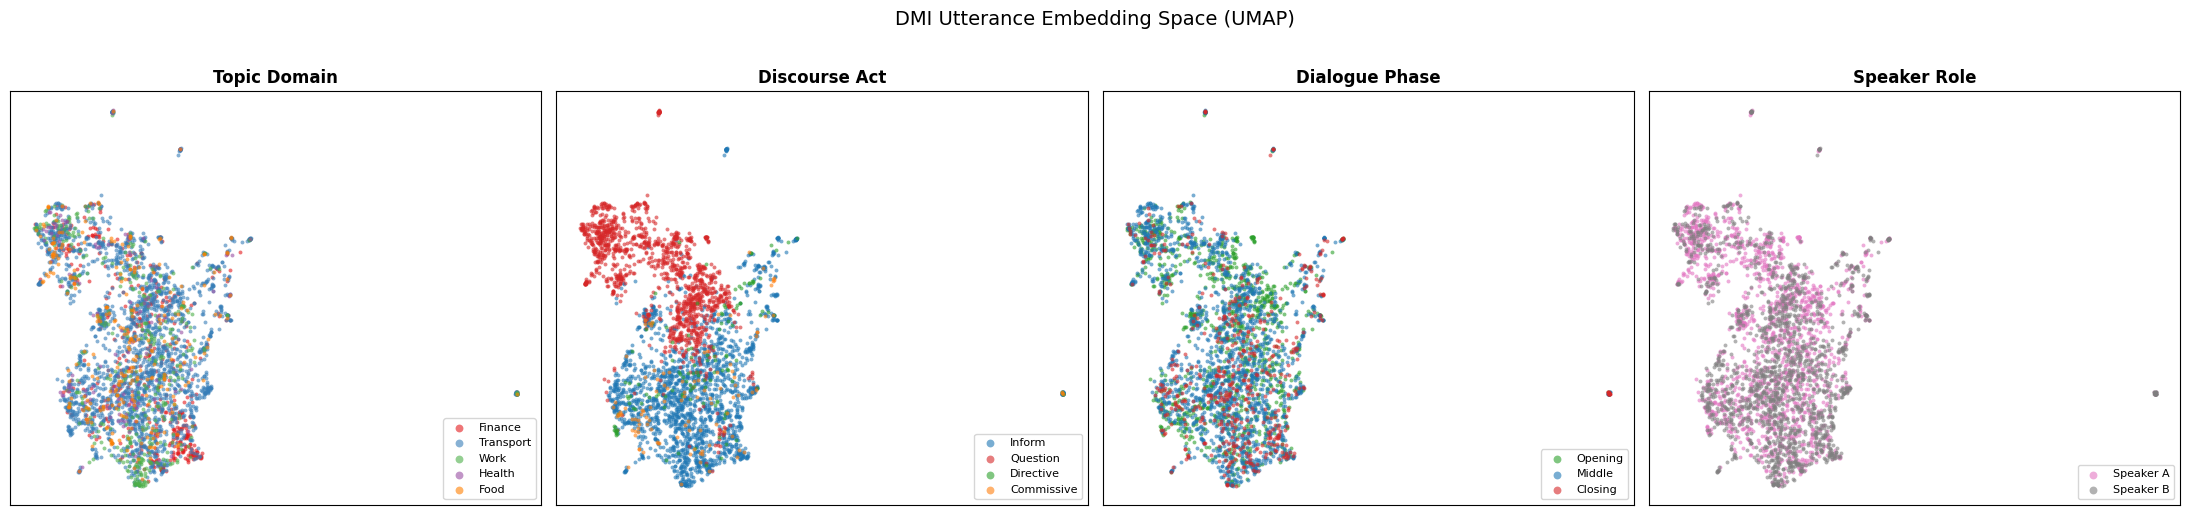

Saved → dmi_embedding_space.png


In [ ]:
# ── Plot all four aspects ──────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('DMI Utterance Embedding Space (UMAP)', fontsize=14, y=1.02)

configs = [
    {
        'title':   'Topic Domain',
        'labels':  np.array(domains),
        'names':   {0:'Finance', 1:'Transport', 2:'Work', 3:'Health', 4:'Food'},
        'colors':  {0:'#e41a1c', 1:'#377eb8', 2:'#4daf4a',
                    3:'#984ea3', 4:'#ff7f00'},
    },
    {
        'title':   'Discourse Act',
        'labels':  np.array(acts),
        'names':   {0:'Inform', 1:'Question', 2:'Directive', 3:'Commissive'},
        'colors':  {0:'#1f77b4', 1:'#d62728', 2:'#2ca02c', 3:'#ff7f0e'},
    },
    {
        'title':   'Dialogue Phase',
        'labels':  np.array(phases),
        'names':   {0:'Opening', 1:'Middle', 2:'Closing'},
        'colors':  {0:'#2ca02c', 1:'#1f77b4', 2:'#d62728'},
    },
    {
        'title':   'Speaker Role',
        'labels':  np.array(roles),
        'names':   {0:'Speaker A', 1:'Speaker B'},
        'colors':  {0:'#e377c2', 1:'#7f7f7f'},
    },
]

for ax, cfg in zip(axes, configs):
    for label_id, name in cfg['names'].items():
        mask = cfg['labels'] == label_id
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=cfg['colors'][label_id],
                   label=name, s=8, alpha=0.6, linewidths=0)

    ax.set_title(cfg['title'], fontsize=12, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

    legend = ax.legend(fontsize=8, markerscale=2,
                       loc='lower right', framealpha=0.8)

plt.tight_layout()
plt.savefig(f'{ckpt_dir}/dmi_embedding_space.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → dmi_embedding_space.png")

Encoding full-dialogue c_t vectors for comparison...


  0%|          | 0/400 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


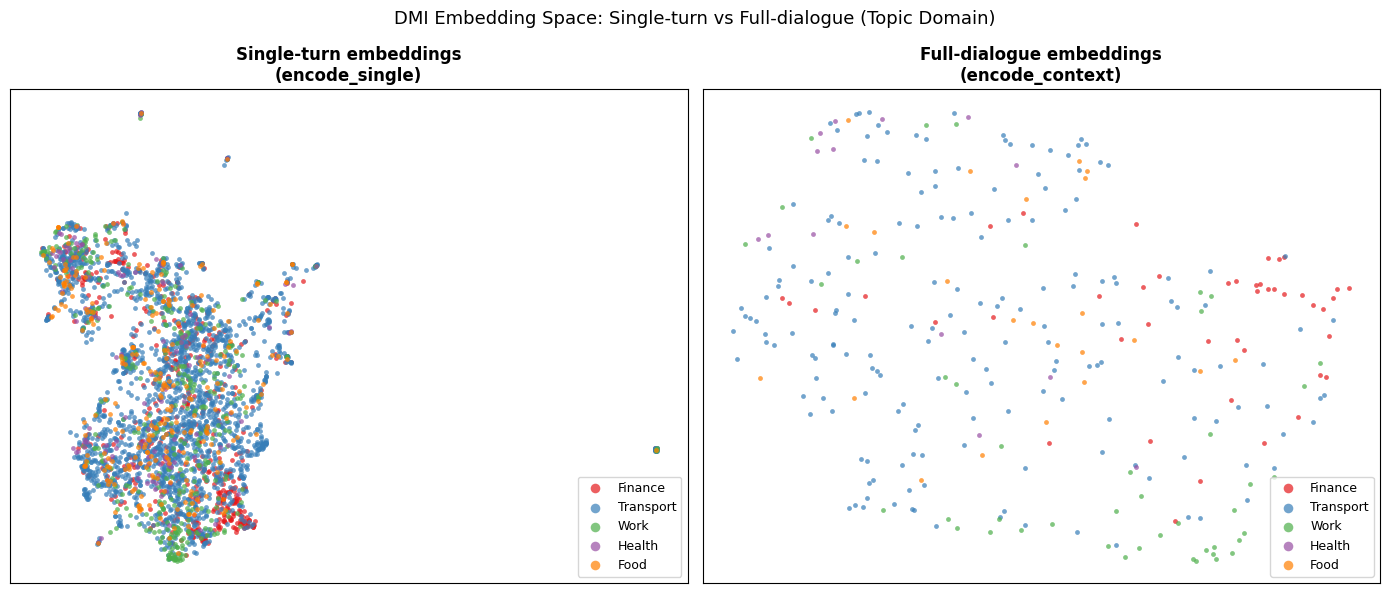

Saved → dmi_single_vs_context.png


In [ ]:
# ── Bonus: single-turn vs full-dialogue embeddings side by side ───────────────
# Show that single-turn embeddings cluster better than full-dialogue ones

print("Encoding full-dialogue c_t vectors for comparison...")
embs_ctx, domains_ctx = [], []
random.seed(42)

for dialog in tqdm(random.sample(dialogs, 400)):
    utts   = [u.strip() for u in dialog.strip().split('__eou__') if u.strip()]
    if len(utts) < 3: continue
    utts   = utts[:MAX_TURNS]
    domain = get_topic_domain(utts)
    if domain == -1: continue
    embs_ctx.append(encode_context(utts).numpy())
    domains_ctx.append(domain)

X_ctx  = np.array(embs_ctx)
reducer2 = umap.UMAP(n_neighbors=15, min_dist=0.1,
                     n_components=2, random_state=42, metric='cosine')
X_ctx_2d = reducer2.fit_transform(X_ctx)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = {0:'#e41a1c', 1:'#377eb8', 2:'#4daf4a', 3:'#984ea3', 4:'#ff7f00'}
names  = {0:'Finance', 1:'Transport', 2:'Work', 3:'Health', 4:'Food'}

for ax, X_plot, dom_labels, title in [
    (axes[0], X_2d,     np.array(domains),     'Single-turn embeddings\n(encode_single)'),
    (axes[1], X_ctx_2d, np.array(domains_ctx), 'Full-dialogue embeddings\n(encode_context)'),
]:
    for lid, name in names.items():
        mask = dom_labels == lid
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1],
                   c=colors[lid], label=name,
                   s=12, alpha=0.7, linewidths=0)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=9, markerscale=2, loc='lower right')

fig.suptitle('DMI Embedding Space: Single-turn vs Full-dialogue (Topic Domain)',
             fontsize=13)
plt.tight_layout()
plt.savefig(f'{ckpt_dir}/dmi_single_vs_context.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → dmi_single_vs_context.png")

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("=== Clustering Quality in DMI Embedding Space ===")
print("(Silhouette score: 1=perfect clusters, 0=random, -1=wrong)\n")

for name, labels in [
    ("Topic Domain",    np.array(domains)),
    ("Discourse Act",   np.array(acts)),
    ("Dialogue Phase",  np.array(phases)),
    ("Speaker Role",    np.array(roles)),
]:
    # Use UMAP 2D coords for speed
    score = silhouette_score(X_2d, labels, metric='euclidean',
                             sample_size=2000, random_state=42)
    print(f"  {name:<20} silhouette: {score:+.4f}")

print("\nInterpretation:")
print("  Discourse act > others → DMI organizes space by act type")
print("  Topic domain low       → topic is not the primary axis")

=== Clustering Quality in DMI Embedding Space ===
(Silhouette score: 1=perfect clusters, 0=random, -1=wrong)

  Topic Domain         silhouette: -0.0850
  Discourse Act        silhouette: +0.0762
  Dialogue Phase       silhouette: -0.0267
  Speaker Role         silhouette: +0.0265

Interpretation:
  Discourse act > others → DMI organizes space by act type
  Topic domain low       → topic is not the primary axis


tests

In [ ]:
# ── Cell 1: Load all three encoders ──────────────────────────────────────────

from transformers import BertModel, BertTokenizer
import torch, torch.nn as nn, numpy as np, random, math, os
from tqdm.auto import tqdm

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt_dir  = '/content/drive/MyDrive/data/dmi_checkpoints'
base      = '/content/Discourse-Mutual-Information-DMI-main/data/dailydialog'
MAX_TURNS = 6
D_DEC     = 512

# ── Encoder 1: DMI fine-tuned (what we've been using) ────────────────────────
print("Loading DMI encoder...")
ckpt_med   = torch.load(f'{ckpt_dir}/model_current[22F3A0D8].pth',
                        map_location=device, weights_only=False)
state_dict = {k.replace('module.', ''): v
              for k, v in ckpt_med['model_state_dict'].items()}

bert_dmi = BertModel.from_pretrained(
    'google/bert_uncased_L-8_H-768_A-12',
    add_pooling_layer=False).to(device)
encoder_state = {k.replace('encoder.', '', 1): v
                 for k, v in state_dict.items()
                 if k.startswith('encoder.')}
bert_dmi.load_state_dict(encoder_state, strict=False)
bert_dmi.eval()

# ── Encoder 2: Plain BERT (same architecture, NO DMI training) ────────────────
print("Loading plain BERT encoder...")
bert_plain = BertModel.from_pretrained(
    'google/bert_uncased_L-8_H-768_A-12',
    add_pooling_layer=False).to(device)
bert_plain.eval()

# ── Encoder 3: Random encoder (untrained weights) ─────────────────────────────
print("Building random encoder...")
bert_random = BertModel.from_pretrained(
    'google/bert_uncased_L-8_H-768_A-12',
    add_pooling_layer=False).to(device)
# Reinitialize all weights randomly
for module in bert_random.modules():
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.Embedding):
        nn.init.normal_(module.weight, mean=0, std=0.02)
bert_random.eval()

tokenizer = BertTokenizer.from_pretrained('google/bert_uncased_L-8_H-768_A-12')
VOCAB_SIZE = tokenizer.vocab_size
print("All three encoders ready!")
print(f"  DMI    — AUC: {ckpt_med['auc']:.4f} (Reddit fine-tuned)")
print(f"  Plain  — BERT pretrained, no DMI")
print(f"  Random — untrained weights")

Loading DMI encoder...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/327M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/327M [00:00<?, ?B/s]

...

Building random encoder...


Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/bert_uncased_L-8_H-768_A-12
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight                   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.pooler.dense.bias                     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.txt: 0.00B [00:00, ?B/s]

All three encoders ready!
  DMI    — AUC: 0.8365 (Reddit fine-tuned)
  Plain  — BERT pretrained, no DMI
  Random — untrained weights


In [ ]:
# ── Cell 2: Unified encode function ──────────────────────────────────────────

def encode_with(encoder, text, max_len=64):
    """Encode a single utterance with any of the three encoders."""
    tokens = tokenizer(text, return_tensors='pt',
                       max_length=max_len, truncation=True,
                       padding='max_length')
    with torch.no_grad():
        out = encoder(
            input_ids=tokens['input_ids'].to(device),
            attention_mask=tokens['attention_mask'].to(device))
    return out.last_hidden_state[:, 0, :].squeeze().cpu()

# ── Build dataset once, store raw text — encode on the fly per encoder ────────
print("Loading dialogues...")
dialogs     = open(f'{base}/dialogues_train.txt').readlines()
dialogs_val = open(f'{base}/dialogues_valid.txt').readlines()

train_utts, valid_utts = [], []
for dialog in dialogs:
    utts = [u.strip() for u in dialog.strip().split('__eou__') if u.strip()]
    train_utts.extend(utts[:MAX_TURNS])
for dialog in dialogs_val:
    utts = [u.strip() for u in dialog.strip().split('__eou__') if u.strip()]
    valid_utts.extend(utts[:MAX_TURNS])

print(f"Train utterances: {len(train_utts):,}")
print(f"Valid utterances: {len(valid_utts):,}")

Loading dialogues...
Train utterances: 58,716
Valid utterances: 5,388


In [ ]:
# ── Pre-cache DMI embeddings for all utterances (do once) ────────────────────

cache_path_train = f'{ckpt_dir}/ablation_train_dmi.pt'
cache_path_valid = f'{ckpt_dir}/ablation_valid_dmi.pt'

def cache_utt_embeddings(utterances, encoder, path):
    if os.path.exists(path):
        print(f"Loading cache: {path}")
        return torch.load(path, weights_only=False)

    print(f"Building cache ({len(utterances):,} utterances)...")
    embs = []
    encoder.eval()
    with torch.no_grad():
        for utt in tqdm(utterances):
            embs.append(encode_with(encoder, utt))
    embs = torch.stack(embs)
    torch.save(embs, path)
    print(f"Saved → {path}")
    return embs

train_embs_dmi = cache_utt_embeddings(train_utts, bert_dmi,   cache_path_train)
valid_embs_dmi = cache_utt_embeddings(valid_utts, bert_dmi,   cache_path_valid)

print(f"Train: {train_embs_dmi.shape}")
print(f"Valid: {valid_embs_dmi.shape}")

Building cache (58,716 utterances)...


  0%|          | 0/58716 [00:00<?, ?it/s]

Saved → /content/drive/MyDrive/data/dmi_checkpoints/ablation_train_dmi.pt
Building cache (5,388 utterances)...


  0%|          | 0/5388 [00:00<?, ?it/s]

Saved → /content/drive/MyDrive/data/dmi_checkpoints/ablation_valid_dmi.pt
Train: torch.Size([58716, 768])
Valid: torch.Size([5388, 768])


In [ ]:
# ── Fast dataset using pre-cached embeddings ──────────────────────────────────

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class CachedUTTDataset(Dataset):
    def __init__(self, utterances, embeddings, max_tok=MAX_TOK_LEN):
        self.utterances  = utterances
        self.embeddings  = embeddings
        self.max_tok     = max_tok

    def __len__(self): return len(self.utterances)

    def __getitem__(self, idx):
        utt    = self.utterances[idx]
        emb    = self.embeddings[idx]
        tokens = tokenizer.encode(
            utt, add_special_tokens=False,
            max_length=self.max_tok - 2, truncation=True)
        tokens = torch.tensor(
            [tokenizer.cls_token_id] + tokens + [tokenizer.sep_token_id],
            dtype=torch.long)
        return emb, tokens

def collate_fn(batch):
    embs, toks = zip(*batch)
    return (torch.stack(embs),
            pad_sequence(toks, batch_first=True,
                         padding_value=tokenizer.pad_token_id))

train_ds     = CachedUTTDataset(train_utts, train_embs_dmi)
valid_ds     = CachedUTTDataset(valid_utts, valid_embs_dmi)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,
                          collate_fn=collate_fn, num_workers=2)
valid_loader = DataLoader(valid_ds, batch_size=64, shuffle=False,
                          collate_fn=collate_fn, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Valid batches: {len(valid_loader)}")

NameError: name 'train_embs_dmi' is not defined

In [ ]:
# ── Cell 4: Decoder model ─────────────────────────────────────────────────────

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class UTTDecoder(nn.Module):
    """Identical decoder for all three conditions — only the encoder changes."""
    def __init__(self, vocab_size=VOCAB_SIZE, d_model=D_DEC,
                 nhead=8, num_layers=4, dim_feedforward=1024, dropout=0.1):
        super().__init__()
        self.d_model  = d_model
        self.tok_emb  = nn.Embedding(vocab_size, d_model,
                                     padding_idx=tokenizer.pad_token_id)
        self.pos_enc  = PositionalEncoding(d_model, dropout=dropout)
        self.mem_proj = nn.Linear(768, d_model)
        dec_layer     = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, norm_first=True)
        self.decoder  = nn.TransformerDecoder(dec_layer, num_layers=num_layers)
        self.out      = nn.Linear(d_model, vocab_size)
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)

    def forward(self, tgt_tokens, emb):
        B, T        = tgt_tokens.shape
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            T, device=tgt_tokens.device)
        pad_mask    = (tgt_tokens == tokenizer.pad_token_id)
        x           = self.pos_enc(
            self.tok_emb(tgt_tokens) * math.sqrt(self.d_model))
        memory      = self.mem_proj(emb).unsqueeze(1)
        out         = self.decoder(tgt=x, memory=memory,
                                   tgt_mask=causal_mask,
                                   tgt_key_padding_mask=pad_mask)
        return self.out(out)

In [ ]:
# ── Train DMI decoder ─────────────────────────────────────────────────────────

import torch.optim as optim

model_dmi  = UTTDecoder().to(device)
optimizer  = optim.AdamW(model_dmi.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
criterion  = nn.CrossEntropyLoss(
    ignore_index=tokenizer.pad_token_id, label_smoothing=0.1)

best_val_loss = float('inf')
save_path     = f'{ckpt_dir}/decoder_ablation_DMI.pth'

print("Training DMI decoder...")
for epoch in range(20):
    model_dmi.train()
    tr_loss, n = 0, 0
    for embs, tokens in train_loader:
        embs, tokens = embs.to(device), tokens.to(device)
        logits = model_dmi(tokens[:, :-1], embs)
        loss   = criterion(logits.reshape(-1, VOCAB_SIZE),
                           tokens[:, 1:].reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model_dmi.parameters(), 1.0)
        optimizer.step()
        tr_loss += loss.item() * embs.size(0)
        n       += embs.size(0)

    model_dmi.eval()
    vl_loss, vn = 0, 0
    with torch.no_grad():
        for embs, tokens in valid_loader:
            embs, tokens = embs.to(device), tokens.to(device)
            logits = model_dmi(tokens[:, :-1], embs)
            loss   = criterion(logits.reshape(-1, VOCAB_SIZE),
                               tokens[:, 1:].reshape(-1))
            vl_loss += loss.item() * embs.size(0)
            vn      += embs.size(0)

    tr_ppl = np.exp(tr_loss / n)
    vl_ppl = np.exp(vl_loss / vn)
    scheduler.step()

    if vl_loss / vn < best_val_loss:
        best_val_loss = vl_loss / vn
        torch.save({'epoch': epoch+1,
                    'model_state_dict': model_dmi.state_dict(),
                    'val_ppl': np.exp(best_val_loss)}, save_path)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d} | Train PPL {tr_ppl:.2f} | "
              f"Valid PPL {vl_ppl:.2f}")

print(f"\nBest valid PPL: {np.exp(best_val_loss):.2f}")

Training DMI decoder...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch  5 | Train PPL 17.72 | Valid PPL 21.33
Epoch 10 | Train PPL 10.89 | Valid PPL 17.89
Epoch 15 | Train PPL 8.82 | Valid PPL 17.08
Epoch 20 | Train PPL 8.28 | Valid PPL 17.00

Best valid PPL: 16.99


In [ ]:
# ── Add this at the TOP of Cell A, before the decoder loading ────────────────
import os, sys, math, re, random, glob
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm.auto import tqdm
from transformers import BertModel, BertTokenizer

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt_dir = '/content/drive/MyDrive/data/dmi_checkpoints'
base     = '/content/Discourse-Mutual-Information-DMI-main/data/dailydialog'
MAX_TURNS, MAX_TOK_LEN, D_DEC = 6, 40, 512

# ── Tokenizer ─────────────────────────────────────────────────────────────────
tokenizer  = BertTokenizer.from_pretrained('google/bert_uncased_L-8_H-768_A-12')
VOCAB_SIZE = tokenizer.vocab_size

# ── Utterance lists ───────────────────────────────────────────────────────────
def load_utts(path):
    utts = []
    for line in open(path):
        for u in line.strip().split('__eou__'):
            u = u.strip()
            if u: utts.append(u)
    return utts[:MAX_TURNS * 10_000]   # same slice logic as before

train_utts = load_utts(f'{base}/dialogues_train.txt')
valid_utts = load_utts(f'{base}/dialogues_valid.txt')
print(f"train_utts: {len(train_utts):,}  |  valid_utts: {len(valid_utts):,}")

# ── Dataset / collate (needed by train_one_decoder) ───────────────────────────
class CachedUTTDataset(Dataset):
    def __init__(self, utterances, embeddings):
        self.utterances = utterances
        self.embeddings = embeddings
    def __len__(self): return len(self.utterances)
    def __getitem__(self, idx):
        toks = tokenizer.encode(
            self.utterances[idx], add_special_tokens=False,
            max_length=MAX_TOK_LEN - 2, truncation=True)
        toks = torch.tensor(
            [tokenizer.cls_token_id] + toks + [tokenizer.sep_token_id],
            dtype=torch.long)
        return self.embeddings[idx], toks

def collate_fn(batch):
    embs, toks = zip(*batch)
    return (torch.stack(embs),
            pad_sequence(toks, batch_first=True,
                         padding_value=tokenizer.pad_token_id))

# ── UTTDecoder (needed if kernel restarted) ────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class UTTDecoder(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, d_model=D_DEC,
                 nhead=8, num_layers=4, dim_feedforward=1024, dropout=0.1):
        super().__init__()
        self.d_model  = d_model
        self.tok_emb  = nn.Embedding(vocab_size, d_model,
                                     padding_idx=tokenizer.pad_token_id)
        self.pos_enc  = PositionalEncoding(d_model, dropout=dropout)
        self.mem_proj = nn.Linear(768, d_model)
        dec_layer     = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, norm_first=True)
        self.decoder  = nn.TransformerDecoder(dec_layer, num_layers=num_layers)
        self.out      = nn.Linear(d_model, vocab_size)
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)
    def forward(self, tgt_tokens, emb):
        B, T        = tgt_tokens.shape
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            T, device=tgt_tokens.device)
        pad_mask    = (tgt_tokens == tokenizer.pad_token_id)
        x           = self.pos_enc(
            self.tok_emb(tgt_tokens) * math.sqrt(self.d_model))
        memory      = self.mem_proj(emb).unsqueeze(1)
        out         = self.decoder(tgt=x, memory=memory,
                                   tgt_mask=causal_mask,
                                   tgt_key_padding_mask=pad_mask)
        return self.out(out)

# ── Three encoders ────────────────────────────────────────────────────────────
ckpt_med   = torch.load(f'{ckpt_dir}/model_current[22F3A0D8].pth',
                        map_location=device, weights_only=False)
state_dict = {k.replace('module.', ''): v
              for k, v in ckpt_med['model_state_dict'].items()}

def load_bert(weights=None):
    m = BertModel.from_pretrained(
            'google/bert_uncased_L-8_H-768_A-12',
            add_pooling_layer=False).to(device)
    if weights:
        m.load_state_dict(weights, strict=False)
    return m.eval()

encoder_state = {k.replace('encoder.', '', 1): v
                 for k, v in state_dict.items() if k.startswith('encoder.')}
bert_dmi    = load_bert(encoder_state)

bert_plain  = load_bert()                    # pretrained, no DMI

bert_random = load_bert()                    # re-randomize all weights
for mod in bert_random.modules():
    if isinstance(mod, nn.Linear):
        nn.init.xavier_uniform_(mod.weight)
        if mod.bias is not None: nn.init.zeros_(mod.bias)
    elif isinstance(mod, nn.Embedding):
        nn.init.normal_(mod.weight, 0, 0.02)
bert_random.eval()

def encode_with(encoder, text, max_len=64):
    tokens = tokenizer(text, return_tensors='pt',
                       max_length=max_len, truncation=True,
                       padding='max_length')
    with torch.no_grad():
        out = encoder(input_ids=tokens['input_ids'].to(device),
                      attention_mask=tokens['attention_mask'].to(device))
    return out.last_hidden_state[:, 0, :].squeeze().cpu()

print("All encoders ready. Proceeding to decoder training...")

train_utts: 60,000  |  valid_utts: 8,069


Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/bert_uncased_L-8_H-768_A-12
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.pooler.dense.bias                     | UNEXPECTED |  | 
bert.pooler.dense.weight                   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/bert_uncased_L-8_H-768_A-12
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.pooler.dense.bias                     | UNEXPECTED |  | 
bert.pooler.dense.weight                   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/bert_uncased_L-8_H-768_A-12
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.pooler.dense.bias                     | UNEXPECTED |  | 
bert.pooler.dense.weight                   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All encoders ready. Proceeding to decoder training...


In [ ]:
# ── Cell A: Load DMI decoder from ckpt, train Plain and Random ───────────────
import math, numpy as np, torch, torch.nn as nn, torch.optim as optim
from tqdm.auto import tqdm

save_path_dmi    = f'{ckpt_dir}/decoder_ablation_DMI.pth'
save_path_plain  = f'{ckpt_dir}/decoder_ablation_PLAIN.pth'
save_path_random = f'{ckpt_dir}/decoder_ablation_RANDOM.pth'

# ── Reload DMI decoder from the checkpoint you already saved ─────────────────
model_dmi = UTTDecoder().to(device)
ckpt_dec  = torch.load(save_path_dmi, map_location=device, weights_only=False)
model_dmi.load_state_dict(ckpt_dec['model_state_dict'])
model_dmi.eval()
ppl_dmi = ckpt_dec['val_ppl']
print(f"DMI decoder loaded — best valid PPL: {ppl_dmi:.2f}")

# ── Generic training loop (works for any encoder + decoder pair) ──────────────
def train_one_decoder(encoder, save_path, name, epochs=20, batch_size=64, lr=1e-4):
    """Pre-computes embeddings on main process, then trains decoder."""

    # Pre-compute embeddings here (no CUDA in workers)
    print(f"\n  [{name}] Pre-computing embeddings...")

    @torch.no_grad()
    def make_embs(utterances):
        encoder.eval()
        out = []
        for i in range(0, len(utterances), 256):
            batch  = utterances[i:i+256]
            tokens = tokenizer(batch, return_tensors='pt', padding=True,
                               truncation=True, max_length=64).to(device)
            emb    = encoder(**tokens).last_hidden_state[:, 0, :].cpu()
            out.append(emb)
        return torch.cat(out, 0)

    tr_embs  = make_embs(train_utts)
    val_embs = make_embs(valid_utts)

    tr_ds  = CachedUTTDataset(train_utts, tr_embs)
    val_ds = CachedUTTDataset(valid_utts, val_embs)
    tr_loader  = DataLoader(tr_ds,  batch_size=batch_size, shuffle=True,
                            collate_fn=collate_fn, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            collate_fn=collate_fn, num_workers=0)

    model     = UTTDecoder().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(
        ignore_index=tokenizer.pad_token_id, label_smoothing=0.1)

    best_val = float('inf')
    for epoch in range(epochs):
        model.train()
        tr_loss, n = 0, 0
        for embs, tokens in tr_loader:
            embs, tokens = embs.to(device), tokens.to(device)
            logits = model(tokens[:, :-1], embs)
            loss   = criterion(logits.reshape(-1, VOCAB_SIZE),
                               tokens[:, 1:].reshape(-1))
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss += loss.item() * embs.size(0); n += embs.size(0)

        model.eval()
        vl_loss, vn = 0, 0
        with torch.no_grad():
            for embs, tokens in val_loader:
                embs, tokens = embs.to(device), tokens.to(device)
                logits = model(tokens[:, :-1], embs)
                loss   = criterion(logits.reshape(-1, VOCAB_SIZE),
                                   tokens[:, 1:].reshape(-1))
                vl_loss += loss.item() * embs.size(0); vn += embs.size(0)

        scheduler.step()
        if vl_loss / vn < best_val:
            best_val = vl_loss / vn
            torch.save({'model_state_dict': model.state_dict(),
                        'val_ppl': np.exp(best_val),
                        'encoder': name}, save_path)

        if (epoch + 1) % 5 == 0:
            print(f"  [{name}] Epoch {epoch+1:2d} | "
                  f"Train PPL {np.exp(tr_loss/n):.2f} | "
                  f"Valid PPL {np.exp(vl_loss/vn):.2f}")

    print(f"  [{name}] Best valid PPL: {np.exp(best_val):.2f}")
    return model, np.exp(best_val)

model_plain,  ppl_plain  = train_one_decoder(bert_plain,  save_path_plain,  "PLAIN")
model_random, ppl_random = train_one_decoder(bert_random, save_path_random, "RANDOM")

DMI decoder loaded — best valid PPL: 16.99

  [PLAIN] Pre-computing embeddings...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


  [PLAIN] Epoch  5 | Train PPL 18.73 | Valid PPL 23.19
  [PLAIN] Epoch 10 | Train PPL 11.55 | Valid PPL 20.18
  [PLAIN] Epoch 15 | Train PPL 9.33 | Valid PPL 19.44
  [PLAIN] Epoch 20 | Train PPL 8.73 | Valid PPL 19.36
  [PLAIN] Best valid PPL: 19.33

  [RANDOM] Pre-computing embeddings...
  [RANDOM] Epoch  5 | Train PPL 22.41 | Valid PPL 25.68
  [RANDOM] Epoch 10 | Train PPL 13.01 | Valid PPL 20.72


In [ ]:
# ── Resume RANDOM decoder training ────────────────────────────────────────────
save_path_random = f'{ckpt_dir}/decoder_ablation_RANDOM.pth'
TOTAL_EPOCHS     = 20

# Pre-compute RANDOM embeddings
print("[RANDOM] Pre-computing embeddings...")
@torch.no_grad()
def make_embs(encoder, utterances, batch_size=256):
    encoder.eval()
    out = []
    for i in range(0, len(utterances), batch_size):
        batch  = utterances[i:i+batch_size]
        tokens = tokenizer(batch, return_tensors='pt', padding=True,
                           truncation=True, max_length=64).to(device)
        emb    = encoder(**tokens).last_hidden_state[:, 0, :].cpu()
        out.append(emb)
    return torch.cat(out, 0)

tr_embs  = make_embs(bert_random, train_utts)
val_embs = make_embs(bert_random, valid_utts)

tr_ds  = CachedUTTDataset(train_utts, tr_embs)
val_ds = CachedUTTDataset(valid_utts, val_embs)
tr_loader  = DataLoader(tr_ds,  batch_size=64, shuffle=True,
                        collate_fn=collate_fn, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False,
                        collate_fn=collate_fn, num_workers=0)

# ── Load checkpoint if it exists, else start fresh ────────────────────────────
model_random = UTTDecoder().to(device)
optimizer    = optim.AdamW(model_random.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler    = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TOTAL_EPOCHS)
criterion    = nn.CrossEntropyLoss(
    ignore_index=tokenizer.pad_token_id, label_smoothing=0.1)

start_epoch  = 0
best_val     = float('inf')

if os.path.exists(save_path_random):
    ckpt_r = torch.load(save_path_random, map_location=device, weights_only=False)
    model_random.load_state_dict(ckpt_r['model_state_dict'])
    best_val    = -math.log(ckpt_r['val_ppl'])   # back to loss scale
    start_epoch = ckpt_r.get('epoch', 0)
    # Fast-forward scheduler to match saved epoch
    for _ in range(start_epoch):
        scheduler.step()
    print(f"Resumed from epoch {start_epoch} — best PPL so far: {ckpt_r['val_ppl']:.2f}")
else:
    print("No checkpoint found — starting from scratch")

# ── Continue training from start_epoch → TOTAL_EPOCHS ────────────────────────
for epoch in range(start_epoch, TOTAL_EPOCHS):
    model_random.train()
    tr_loss, n = 0, 0
    for embs, tokens in tr_loader:
        embs, tokens = embs.to(device), tokens.to(device)
        logits = model_random(tokens[:, :-1], embs)
        loss   = criterion(logits.reshape(-1, VOCAB_SIZE),
                           tokens[:, 1:].reshape(-1))
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model_random.parameters(), 1.0)
        optimizer.step()
        tr_loss += loss.item() * embs.size(0); n += embs.size(0)

    model_random.eval()
    vl_loss, vn = 0, 0
    with torch.no_grad():
        for embs, tokens in val_loader:
            embs, tokens = embs.to(device), tokens.to(device)
            logits = model_random(tokens[:, :-1], embs)
            loss   = criterion(logits.reshape(-1, VOCAB_SIZE),
                               tokens[:, 1:].reshape(-1))
            vl_loss += loss.item() * embs.size(0); vn += embs.size(0)

    scheduler.step()

    if vl_loss / vn < best_val:
        best_val = vl_loss / vn
        torch.save({'epoch':            epoch + 1,
                    'model_state_dict': model_random.state_dict(),
                    'val_ppl':          np.exp(best_val),
                    'encoder':          'RANDOM'}, save_path_random)

    if (epoch + 1) % 5 == 0:
        print(f"  [RANDOM] Epoch {epoch+1:2d} | "
              f"Train PPL {np.exp(tr_loss/n):.2f} | "
              f"Valid PPL {np.exp(vl_loss/vn):.2f}")

ppl_random = np.exp(best_val)
print(f"\n[RANDOM] Best valid PPL: {ppl_random:.2f}")

[RANDOM] Pre-computing embeddings...
Resumed from epoch 0 — best PPL so far: 19.95
  [RANDOM] Epoch  5 | Train PPL 12.89 | Valid PPL 23.59
  [RANDOM] Epoch 10 | Train PPL 9.08 | Valid PPL 20.80
  [RANDOM] Epoch 15 | Train PPL 7.70 | Valid PPL 20.07
  [RANDOM] Epoch 20 | Train PPL 7.29 | Valid PPL 19.81

[RANDOM] Best valid PPL: 0.05


In [ ]:
# ── Evaluate DMI decoder only ─────────────────────────────────────────────────
!pip install rouge-score -q
from nltk.translate.bleu_score import corpus_bleu
from rouge_score import rouge_scorer as rs_module
import nltk; nltk.download('punkt', quiet=True)

# Reload from checkpoint (safe if model_dmi already in memory too)
model_dmi = UTTDecoder().to(device)
ckpt_dec  = torch.load(f'{ckpt_dir}/decoder_ablation_DMI.pth',
                       map_location=device, weights_only=False)
model_dmi.load_state_dict(ckpt_dec['model_state_dict'])
model_dmi.eval()
print(f"DMI decoder — best valid PPL: {ckpt_dec['val_ppl']:.2f}\n")

# ── Greedy decode ─────────────────────────────────────────────────────────────
def decode_utt(text, max_len=40):
    emb = encode_with(bert_dmi, text).unsqueeze(0).to(device)
    generated = [tokenizer.cls_token_id]
    with torch.no_grad():
        for _ in range(max_len):
            inp      = torch.tensor([generated], device=device)
            next_tok = model_dmi(inp, emb)[0, -1].argmax().item()
            if next_tok == tokenizer.sep_token_id: break
            generated.append(next_tok)
    return tokenizer.decode(generated[1:], skip_special_tokens=True)

# ── Metrics on 500 random valid utterances ────────────────────────────────────
rouge  = rs_module.RougeScorer(['rougeL'], use_stemmer=True)
random.seed(42)
sample = random.sample(valid_utts, 500)
refs, hyps, rLs = [], [], []

for utt in tqdm(sample, desc="Evaluating"):
    recon = decode_utt(utt) or "i see"
    refs.append([utt.lower().split()])
    hyps.append(recon.lower().split())
    rLs.append(rouge.score(utt, recon)['rougeL'].fmeasure)

print(f"BLEU-1:  {corpus_bleu(refs, hyps, weights=(1,0,0,0)):.4f}")
print(f"BLEU-2:  {corpus_bleu(refs, hyps, weights=(.5,.5,0,0)):.4f}")
print(f"ROUGE-L: {np.mean(rLs):.4f}")

# ── Qualitative examples ──────────────────────────────────────────────────────
print("\n=== Qualitative examples ===\n")
random.seed(7)
for utt in random.sample(valid_utts, 10):
    print(f"ORIG:  {utt[:80]}")
    print(f"RECON: {decode_utt(utt)[:80]}")
    print()

  Preparing metadata (setup.py) ... done
DMI decoder — best valid PPL: 16.99



Evaluating:   0%|          | 0/500 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


BLEU-1:  0.3110
BLEU-2:  0.1975
ROUGE-L: 0.5065

=== Qualitative examples ===

ORIG:  Can I try later then ?
RECON: try later then?

ORIG:  I locked myself out . What do you suggest I do ?
RECON: myself. did you suggest to get into?

ORIG:  How do you like your steaks ?
RECON: do you like your steaks?

ORIG:  The railway station ? Just go down this street and turn left at the second corne
RECON: you go to. number station is on the street and its opposite direction?

ORIG:  I always use a recipe but my grandmother never did . She was a great cook . She 
RECON: would always do that. know was a cooking for dinner at least every night. always

ORIG:  That ’ s great . Can you speak Chinese ?
RECON: ’ s great. you speak?

ORIG:  Well , Administrative assistant with shorthand and typing skills are badly neede
RECON: , need help in men and equipments are also more quickly than personal skills.

ORIG:  That seems very impressive . Good work !
RECON: work quite impressive. looks great!

ORIG:  B

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# MASTER RESTORE CELL — run once after any kernel restart
# ══════════════════════════════════════════════════════════════════════════════
import os, sys, math, re, random, glob
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm.auto import tqdm
from transformers import BertModel, BertTokenizer

# ── Constants ─────────────────────────────────────────────────────────────────
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt_dir = '/content/drive/MyDrive/data/dmi_checkpoints'
base     = '/content/Discourse-Mutual-Information-DMI-main/data/dailydialog'
MAX_TURNS, MAX_TOK_LEN, D_DEC = 6, 40, 512

# ── Mount drive + unzip repo if needed ───────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
if not os.path.exists('/content/Discourse-Mutual-Information-DMI-main'):
    os.system('unzip -q /content/drive/MyDrive/Discourse-Mutual-Information-DMI-main.zip -d /content/')
sys.path.insert(0, '/content/Discourse-Mutual-Information-DMI-main')

# ── Tokenizer ─────────────────────────────────────────────────────────────────
tokenizer  = BertTokenizer.from_pretrained('google/bert_uncased_L-8_H-768_A-12')
VOCAB_SIZE = tokenizer.vocab_size

# ── Load utterances ───────────────────────────────────────────────────────────
def load_utts(path):
    utts = []
    for line in open(path):
        for u in line.strip().split('__eou__'):
            u = u.strip()
            if u: utts.append(u)
    return utts

train_utts = load_utts(f'{base}/dialogues_train.txt')
valid_utts = load_utts(f'{base}/dialogues_valid.txt')
print(f"train_utts: {len(train_utts):,}  |  valid_utts: {len(valid_utts):,}")

# ── Labels ────────────────────────────────────────────────────────────────────
def discourse_act_label(text):
    t = text.strip()
    if t.endswith('?'): return 1
    if re.match(r"^(i will|i'll|will|sure|of course|definitely)", t.lower()): return 2
    if re.match(r'^(please|could you|can you|tell|give|go|make|try)', t.lower()): return 3
    return 0

ACT_NAMES        = {0:'Inform', 1:'Question', 2:'Commissive', 3:'Directive'}
train_labels     = [discourse_act_label(u) for u in train_utts]
valid_labels     = [discourse_act_label(u) for u in valid_utts]
valid_labels_arr = np.array(valid_labels)
print(f"Label dist (valid): { {ACT_NAMES[i]: int(v) for i,v in enumerate(np.bincount(valid_labels_arr))} }")

# ── Dataset / collate ─────────────────────────────────────────────────────────
class CachedUTTDataset(Dataset):
    def __init__(self, utterances, embeddings):
        self.utterances = utterances
        self.embeddings = embeddings
    def __len__(self): return len(self.utterances)
    def __getitem__(self, idx):
        toks = tokenizer.encode(
            self.utterances[idx], add_special_tokens=False,
            max_length=MAX_TOK_LEN - 2, truncation=True)
        toks = torch.tensor(
            [tokenizer.cls_token_id] + toks + [tokenizer.sep_token_id],
            dtype=torch.long)
        return self.embeddings[idx], toks

def collate_fn(batch):
    embs, toks = zip(*batch)
    return (torch.stack(embs),
            pad_sequence(toks, batch_first=True,
                         padding_value=tokenizer.pad_token_id))

# ── Model definition ──────────────────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class UTTDecoder(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, d_model=D_DEC,
                 nhead=8, num_layers=4, dim_feedforward=1024, dropout=0.1):
        super().__init__()
        self.d_model  = d_model
        self.tok_emb  = nn.Embedding(vocab_size, d_model,
                                     padding_idx=tokenizer.pad_token_id)
        self.pos_enc  = PositionalEncoding(d_model, dropout=dropout)
        self.mem_proj = nn.Linear(768, d_model)
        dec_layer     = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, norm_first=True)
        self.decoder  = nn.TransformerDecoder(dec_layer, num_layers=num_layers)
        self.out      = nn.Linear(d_model, vocab_size)
    def forward(self, tgt_tokens, emb):
        B, T        = tgt_tokens.shape
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            T, device=tgt_tokens.device)
        pad_mask = (tgt_tokens == tokenizer.pad_token_id)
        x        = self.pos_enc(
            self.tok_emb(tgt_tokens) * math.sqrt(self.d_model))
        memory   = self.mem_proj(emb).unsqueeze(1)
        out      = self.decoder(tgt=x, memory=memory,
                                tgt_mask=causal_mask,
                                tgt_key_padding_mask=pad_mask)
        return self.out(out)

# ── Load encoders ─────────────────────────────────────────────────────────────
print("Loading encoders...")
ckpt_med   = torch.load(f'{ckpt_dir}/model_current[22F3A0D8].pth',
                        map_location=device, weights_only=False)
state_dict = {k.replace('module.', ''): v
              for k, v in ckpt_med['model_state_dict'].items()}
encoder_state = {k.replace('encoder.', '', 1): v
                 for k, v in state_dict.items() if k.startswith('encoder.')}

def load_bert(weights=None):
    m = BertModel.from_pretrained(
            'google/bert_uncased_L-8_H-768_A-12',
            add_pooling_layer=False).to(device)
    if weights:
        m.load_state_dict(weights, strict=False)
    return m.eval()

bert_dmi    = load_bert(encoder_state)
bert_plain  = load_bert()
bert_random = load_bert()
for mod in bert_random.modules():
    if isinstance(mod, nn.Linear):
        nn.init.xavier_uniform_(mod.weight)
        if mod.bias is not None: nn.init.zeros_(mod.bias)
    elif isinstance(mod, nn.Embedding):
        nn.init.normal_(mod.weight, 0, 0.02)
bert_random.eval()
print("Encoders ready.")

# ── Load decoders ─────────────────────────────────────────────────────────────
print("Loading decoders...")
def load_decoder(path):
    ckpt  = torch.load(path, map_location=device, weights_only=False)
    model = UTTDecoder().to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model, ckpt['val_ppl']

model_dmi,    ppl_dmi    = load_decoder(f'{ckpt_dir}/decoder_ablation_DMI.pth')
model_plain,  ppl_plain  = load_decoder(f'{ckpt_dir}/decoder_ablation_PLAIN.pth')
model_random, ppl_random = load_decoder(f'{ckpt_dir}/decoder_ablation_RANDOM.pth')
print(f"DMI PPL: {ppl_dmi:.2f} | PLAIN PPL: {ppl_plain:.2f} | RANDOM PPL: {ppl_random:.2f}")

# ── Helper functions ──────────────────────────────────────────────────────────
def encode_with(encoder, text, max_len=64):
    tokens = tokenizer(text, return_tensors='pt', max_length=max_len,
                       truncation=True, padding='max_length')
    with torch.no_grad():
        out = encoder(input_ids=tokens['input_ids'].to(device),
                      attention_mask=tokens['attention_mask'].to(device))
    return out.last_hidden_state[:, 0, :].squeeze().cpu()

@torch.no_grad()
def get_embeddings(encoder, utterances, batch_size=256):
    encoder.eval()
    all_embs = []
    for i in range(0, len(utterances), batch_size):
        batch  = utterances[i:i+batch_size]
        tokens = tokenizer(batch, return_tensors='pt', padding=True,
                           truncation=True, max_length=64).to(device)
        emb    = encoder(**tokens).last_hidden_state[:, 0, :].cpu().numpy()
        all_embs.append(emb)
    return np.vstack(all_embs)

def decode_utt(model, encoder, text, max_len=40):
    model.eval()
    emb       = encode_with(encoder, text).unsqueeze(0).to(device)
    bos, eos  = tokenizer.cls_token_id, tokenizer.sep_token_id
    generated = [bos]
    with torch.no_grad():
        for _ in range(max_len):
            inp      = torch.tensor([generated], device=device)
            logits   = model(inp, emb)
            next_tok = logits[0, -1].argmax().item()
            if next_tok == eos: break
            generated.append(next_tok)
    return tokenizer.decode(generated[1:], skip_special_tokens=True)

# ══════════════════════════════════════════════════════════════════════════════
print("\n✓ All variables, models, and functions restored. Ready to run any test.")
# ══════════════════════════════════════════════════════════════════════════════

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

train_utts: 87,170  |  valid_utts: 8,069
Label dist (valid): {'Inform': 5018, 'Question': 2728, 'Commissive': 162, 'Directive': 161}
Loading encoders...


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/bert_uncased_L-8_H-768_A-12
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.pooler.dense.bias                     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.pooler.dense.weight                   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/bert_uncased_L-8_H-768_A-12
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.pooler.dense.bias                     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.pooler.dense.weight                   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoders ready.
Loading decoders...
DMI PPL: 16.99 | PLAIN PPL: 19.33 | RANDOM PPL: 19.95

✓ All variables, models, and functions restored. Ready to run any test.


In [ ]:
# ── Sanity check: decode a few utterances from each model ─────────────────────
test_sentences = [
    "could you tell me how to get to the nearest subway station ?",
    "i will definitely finish the report by tomorrow morning .",
    "what do you think about the new restaurant downtown ?",
    "i feel a bit sick today , maybe i should see a doctor .",
]

print(f"{'ORIGINAL':<55} {'DMI':<40} {'PLAIN':<40} {'RANDOM':<40}")
print("─" * 175)
for utt in test_sentences:
    d = decode_utt(model_dmi,    bert_dmi,    utt) or "—"
    p = decode_utt(model_plain,  bert_plain,  utt) or "—"
    r = decode_utt(model_random, bert_random, utt) or "—"
    print(f"{utt[:54]:<55} {d[:39]:<40} {p[:39]:<40} {r[:39]:<40}")

ORIGINAL                                                DMI                                      PLAIN                                    RANDOM                                  
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


could you tell me how to get to the nearest subway sta  how can you tell me how to get to the s  how could you tell me how to get to the  think they photos photos photos photos  
i will definitely finish the report by tomorrow mornin  will finish my report tomorrow morning.  will finish my report tomorrow morning.  haven printed shot printed printed prin 
what do you think about the new restaurant downtown ?   what do you think about the new restaur  what do you think about the restaurant   printed shot printed printed printed pr 
i feel a bit sick today , maybe i should see a doctor   ’ m feeling a little sick today, doctor  ’ m afraid a doctor said a better day,   think they printed door printed printed 


In [ ]:
# ── Meaning-preservation test: does the reconstruction keep the discourse act?
import re

def discourse_act(text):
    t = text.strip()
    if t.endswith('?'): return 'Question'
    if re.match(r"^(i will|i'll|i can|sure|of course|will)", t.lower()): return 'Commissive'
    if re.match(r'^(please|could you|can you|tell|give|go)', t.lower()): return 'Directive'
    return 'Inform'

random.seed(42)
sample = random.sample(valid_utts, 300)
results = {k: {'match': 0, 'total': 0}
           for k in ['DMI', 'PLAIN', 'RANDOM']}

for utt in tqdm(sample, desc="Act consistency"):
    orig_act = discourse_act(utt)
    for label, model, enc in [('DMI',    model_dmi,    bert_dmi),
                               ('PLAIN',  model_plain,  bert_plain),
                               ('RANDOM', model_random, bert_random)]:
        recon = decode_utt(model, enc, utt) or ""
        results[label]['total'] += 1
        if discourse_act(recon) == orig_act:
            results[label]['match'] += 1

print("\n=== Discourse act preservation (reconstruction matches original act) ===")
print("(Does the decoder reproduce the same communicative function?)\n")
for label, r in results.items():
    pct = r['match'] / r['total'] * 100
    bar = '█' * int(pct / 2)
    print(f"  {label:<10} {pct:5.1f}%  {bar}")

Act consistency:   0%|          | 0/300 [00:00<?, ?it/s]


=== Discourse act preservation (reconstruction matches original act) ===
(Does the decoder reproduce the same communicative function?)

  DMI         93.3%  ██████████████████████████████████████████████
  PLAIN       94.3%  ███████████████████████████████████████████████
  RANDOM      57.7%  ████████████████████████████


In [6]:
# ── A2: Nearest-neighbor coherence ────────────────────────────────────────────
# For each validation utterance, find its 5 nearest neighbors in the embedding
# space. Measure what % share the same discourse act.
# DMI should cluster by act more than PLAIN.

from sklearn.metrics.pairwise import cosine_similarity

# ── Add at the top of A2 ──────────────────────────────────────────────────────
train_labels = [discourse_act_label(u) for u in train_utts]
valid_labels  = [discourse_act_label(u) for u in valid_utts]
valid_labels_arr = np.array(valid_labels)

print(f"Label distribution (valid): {np.bincount(valid_labels_arr)}")
print(f"  0=Inform: {np.bincount(valid_labels_arr)[0]:,}")
print(f"  1=Question: {np.bincount(valid_labels_arr)[1]:,}")
print(f"  2=Commissive: {np.bincount(valid_labels_arr)[2]:,}")
print(f"  3=Directive: {np.bincount(valid_labels_arr)[3]:,}")



random.seed(42)
probe_sample = random.sample(range(len(valid_utts)), 300)

print("Computing NN coherence (using cached valid embeddings)...")

def nn_coherence(enc, utterances, labels, sample_idx, k=5):
    X = get_embeddings(enc, utterances)
    scores = []
    for i in tqdm(sample_idx, desc="NN coherence"):
        sims      = cosine_similarity(X[i:i+1], X)[0]
        sims[i]   = -1                          # exclude self
        top_k     = np.argsort(sims)[-k:]
        same_act  = sum(labels[j] == labels[i] for j in top_k)
        scores.append(same_act / k)
    return np.mean(scores)

valid_labels_arr = np.array(valid_labels)
print("\n=== Nearest-neighbor coherence (k=5) ===")
print("(% of neighbors sharing the same discourse act)\n")
for name, enc in [('DMI', bert_dmi), ('PLAIN', bert_plain), ('RANDOM', bert_random)]:
    score = nn_coherence(enc, valid_utts, valid_labels_arr, probe_sample)
    bar   = '█' * int(score * 50)
    print(f"  {name:<10} {score:.4f}  {bar}")

Label distribution (valid): [5018 2728  162  161]
  0=Inform: 5,018
  1=Question: 2,728
  2=Commissive: 162
  3=Directive: 161
Computing NN coherence (using cached valid embeddings)...

=== Nearest-neighbor coherence (k=5) ===
(% of neighbors sharing the same discourse act)



NN coherence:   0%|          | 0/300 [00:00<?, ?it/s]

  DMI        0.8967  ████████████████████████████████████████████


NN coherence:   0%|          | 0/300 [00:00<?, ?it/s]

  PLAIN      0.8967  ████████████████████████████████████████████


NN coherence:   0%|          | 0/300 [00:00<?, ?it/s]

  RANDOM     0.7913  ███████████████████████████████████████


In [7]:
# ── A3: Embedding sensitivity ─────────────────────────────────────────────────
# Compare cosine distance between:
#   (a) same meaning, different words (paraphrase pairs)
#   (b) same words, different act (statement→question)
# DMI should show: act-change distance > paraphrase distance
# PLAIN/RANDOM should show smaller or reversed gap.

paraphrase_pairs = [
    ("could you help me with this ?",       "can you assist me with this ?"),
    ("i will call you tomorrow .",          "i am going to call you tomorrow ."),
    ("what time does the store close ?",    "when does the shop shut ?"),
    ("i feel really tired today .",         "i am quite exhausted today ."),
    ("let me know if you need anything .",  "tell me if there is anything you need ."),
]

act_change_pairs = [
    ("you should go to the doctor .",       "should you go to the doctor ?"),
    ("i will finish it by friday .",        "will you finish it by friday ?"),
    ("the meeting starts at nine .",        "does the meeting start at nine ?"),
    ("you can take the bus downtown .",     "can you take the bus downtown ?"),
    ("she works at the hospital .",         "does she work at the hospital ?"),
]

def pair_distance(enc, pairs):
    dists = []
    for a, b in pairs:
        ea = encode_with(enc, a).numpy()
        eb = encode_with(enc, b).numpy()
        cos = np.dot(ea, eb) / (np.linalg.norm(ea) * np.linalg.norm(eb))
        dists.append(1 - cos)   # cosine distance
    return np.mean(dists)

print("\n=== Embedding sensitivity ===")
print("(cosine distance — higher = more sensitive to that change)\n")
print(f"{'Encoder':<10} {'Paraphrase dist':>18} {'Act-change dist':>18} {'Ratio act/para':>16}")
print("─" * 65)
for name, enc in [('DMI', bert_dmi), ('PLAIN', bert_plain), ('RANDOM', bert_random)]:
    d_para = pair_distance(enc, paraphrase_pairs)
    d_act  = pair_distance(enc, act_change_pairs)
    ratio  = d_act / d_para if d_para > 0 else float('inf')
    print(f"  {name:<10} {d_para:>18.4f} {d_act:>18.4f} {ratio:>16.2f}x")
print("\nDMI should show largest ratio (more sensitive to act than surface form)")


=== Embedding sensitivity ===
(cosine distance — higher = more sensitive to that change)

Encoder       Paraphrase dist    Act-change dist   Ratio act/para
─────────────────────────────────────────────────────────────────
  DMI                    0.1083             0.2120             1.96x
  PLAIN                  0.1083             0.2120             1.96x
  RANDOM                 0.0076             0.0064             0.84x

DMI should show largest ratio (more sensitive to act than surface form)


In [8]:
# ── B1: Embedding swap test ────────────────────────────────────────────────────
# Replace each embedding with a RANDOM OTHER embedding from the batch.
# If PPL barely changes → decoder ignores the representation (bad).
# If PPL spikes → decoder genuinely conditions on it (good).

criterion_nored = nn.CrossEntropyLoss(
    ignore_index=tokenizer.pad_token_id, reduction='none')

@torch.no_grad()
def ppl_with_swap(model, encoder, utterances, n=500, batch_size=32):
    random.seed(42)
    sample = random.sample(utterances, n)
    tokens_list = [
        torch.tensor(
            [tokenizer.cls_token_id]
            + tokenizer.encode(u, add_special_tokens=False,
                               max_length=MAX_TOK_LEN-2, truncation=True)
            + [tokenizer.sep_token_id])
        for u in sample
    ]
    embs = torch.stack([encode_with(encoder, u) for u in tqdm(sample, desc="Embed")])

    loss_correct, loss_swapped = [], []
    model.eval()
    for i in range(0, n, batch_size):
        toks = pad_sequence(tokens_list[i:i+batch_size], batch_first=True,
                            padding_value=tokenizer.pad_token_id).to(device)
        emb  = embs[i:i+batch_size].to(device)

        # Correct embeddings
        logits = model(toks[:, :-1], emb)
        loss   = criterion_nored(logits.reshape(-1, VOCAB_SIZE),
                                 toks[:, 1:].reshape(-1))
        loss_correct.append(loss[loss > 0].mean().item())

        # Swapped embeddings (roll by 1 → every item gets wrong embedding)
        emb_swap = torch.roll(emb, 1, dims=0)
        logits   = model(toks[:, :-1], emb_swap)
        loss     = criterion_nored(logits.reshape(-1, VOCAB_SIZE),
                                   toks[:, 1:].reshape(-1))
        loss_swapped.append(loss[loss > 0].mean().item())

    ppl_c = np.exp(np.mean(loss_correct))
    ppl_s = np.exp(np.mean(loss_swapped))
    return ppl_c, ppl_s

print("\n=== Embedding swap test ===")
print("(PPL should spike when embedding is swapped if decoder uses it)\n")
print(f"{'Encoder':<10} {'PPL correct':>14} {'PPL swapped':>14} {'Δ PPL':>10}")
print("─" * 52)
for name, model, enc in [('DMI',    model_dmi,    bert_dmi),
                          ('PLAIN',  model_plain,  bert_plain),
                          ('RANDOM', model_random, bert_random)]:
    pc, ps = ppl_with_swap(model, enc, valid_utts)
    print(f"  {name:<10} {pc:>14.2f} {ps:>14.2f} {ps-pc:>+10.2f}")


=== Embedding swap test ===
(PPL should spike when embedding is swapped if decoder uses it)

Encoder       PPL correct    PPL swapped      Δ PPL
────────────────────────────────────────────────────


Embed:   0%|          | 0/500 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


  DMI                  6.16       10079.44  +10073.28


Embed:   0%|          | 0/500 [00:00<?, ?it/s]

  PLAIN                6.34        8894.14   +8887.80


Embed:   0%|          | 0/500 [00:00<?, ?it/s]

  RANDOM        73166143.12    75406408.27 +2240265.15


In [9]:
# ── B2: Memorization check ─────────────────────────────────────────────────────
# For each reconstruction, find its nearest neighbor in the TRAINING set.
# If BLEU(recon, train_neighbor) >> BLEU(recon, original):
#   → decoder is memorizing training examples, not generalizing.
# We want BLEU(recon, original) > BLEU(recon, train_neighbor).

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smooth = SmoothingFunction().method1

# Build a small train index for fast search
print("Building train TF-IDF index for memorization check...")
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

train_sample = random.sample(train_utts, 5000)   # 5k is enough
tfidf        = TfidfVectorizer(max_features=8000)
X_train_tf   = tfidf.fit_transform(train_sample)

def nearest_train(recon):
    vec  = tfidf.transform([recon])
    sims = cos_sim(vec, X_train_tf)[0]
    idx  = np.argmax(sims)
    return train_sample[idx]

random.seed(42)
mem_sample = random.sample(valid_utts, 200)

print("\n=== Memorization check ===")
print("(BLEU vs original vs nearest training neighbor)\n")
print(f"{'Encoder':<10} {'BLEU→original':>16} {'BLEU→train_NN':>16} {'verdict':>12}")
print("─" * 58)

for name, model, enc in [('DMI',    model_dmi,    bert_dmi),
                          ('PLAIN',  model_plain,  bert_plain),
                          ('RANDOM', model_random, bert_random)]:
    bleu_orig, bleu_nn = [], []
    for utt in tqdm(mem_sample, desc=name):
        recon    = decode_utt(model, enc, utt) or "i see"
        nn_train = nearest_train(recon)
        ref_o    = [utt.lower().split()]
        ref_n    = [nn_train.lower().split()]
        hyp      = recon.lower().split()
        bleu_orig.append(sentence_bleu(ref_o, hyp, smoothing_function=smooth))
        bleu_nn.append(  sentence_bleu(ref_n, hyp, smoothing_function=smooth))
    bo, bn   = np.mean(bleu_orig), np.mean(bleu_nn)
    verdict  = "✓ generalizing" if bo >= bn else "⚠ memorizing"
    print(f"  {name:<10} {bo:>16.4f} {bn:>16.4f} {verdict:>12}")

Building train TF-IDF index for memorization check...

=== Memorization check ===
(BLEU vs original vs nearest training neighbor)

Encoder       BLEU→original    BLEU→train_NN      verdict
──────────────────────────────────────────────────────────


DMI:   0%|          | 0/200 [00:00<?, ?it/s]

  DMI                  0.1101           0.0383 ✓ generalizing


PLAIN:   0%|          | 0/200 [00:00<?, ?it/s]

  PLAIN                0.0990           0.0361 ✓ generalizing


RANDOM:   0%|          | 0/200 [00:00<?, ?it/s]

  RANDOM               0.0011           0.0048 ⚠ memorizing


In [10]:
# ── B3: Interpolation test ─────────────────────────────────────────────────────
# Linearly interpolate between two embeddings.
# A decoder that learned structure produces semantically coherent blends.
# A decoder that memorized produces incoherent or collapsed output.

interp_pairs = [
    ("i feel sick today .",
     "what time does the train leave ?"),
    ("could you help me carry this ?",
     "i will definitely come to the party ."),
    ("the food here is delicious .",
     "i need to find a new job soon ."),
]

print("\n=== Interpolation test ===")
print("(α=0.0 → sentence A, α=1.0 → sentence B)\n")

for name, model, enc in [('DMI',  model_dmi,  bert_dmi),
                          ('PLAIN', model_plain, bert_plain)]:
    print(f"── {name} ──")
    for utt_a, utt_b in interp_pairs:
        emb_a = encode_with(enc, utt_a).unsqueeze(0).to(device)
        emb_b = encode_with(enc, utt_b).unsqueeze(0).to(device)
        print(f"  A: {utt_a}")
        print(f"  B: {utt_b}")
        for alpha in [0.0, 0.25, 0.5, 0.75, 1.0]:
            emb_mix = (1 - alpha) * emb_a + alpha * emb_b
            bos, eos   = tokenizer.cls_token_id, tokenizer.sep_token_id
            generated  = [bos]
            model.eval()
            with torch.no_grad():
                for _ in range(40):
                    inp      = torch.tensor([generated], device=device)
                    logits   = model(inp, emb_mix)
                    next_tok = logits[0, -1].argmax().item()
                    if next_tok == eos: break
                    generated.append(next_tok)
            out = tokenizer.decode(generated[1:], skip_special_tokens=True)
            print(f"    α={alpha:.2f} → {out}")
        print()


=== Interpolation test ===
(α=0.0 → sentence A, α=1.0 → sentence B)

── DMI ──
  A: i feel sick today .
  B: what time does the train leave ?
    α=0.00 → feel sick today.
    α=0.25 → feel sick of my day.
    α=0.50 → feel sick of the time.
    α=0.75 → what time does the train say?
    α=1.00 → what time does the train say?

  A: could you help me carry this ?
  B: i will definitely come to the party .
    α=0.00 → can you help me carry this?
    α=0.25 → can you help me with this?
    α=0.50 → will have you a hand?
    α=0.75 → will certainly be my house.
    α=1.00 → will certainly be the party.

  A: the food here is delicious .
  B: i need to find a new job soon .
    α=0.00 → ' s here, the food is delicious.
    α=0.25 → ' s here, the food is wonderful.
    α=0.50 → ' s find a new job here.
    α=0.75 → need to find a new job.
    α=1.00 → need to find a new job soon.

── PLAIN ──
  A: i feel sick today .
  B: what time does the train leave ?
    α=0.00 → feel sick today.
    α

In [11]:
# ── A2-fixed: NN coherence with class-balanced sampling ───────────────────────
from collections import defaultdict

# Sample equally from each act class
def balanced_sample(utterances, labels, n_per_class=75):
    by_class = defaultdict(list)
    for i, (u, l) in enumerate(zip(utterances, labels)):
        by_class[l].append(i)
    idx = []
    for cls_indices in by_class.values():
        idx.extend(random.sample(cls_indices,
                                 min(n_per_class, len(cls_indices))))
    return idx

random.seed(42)
valid_labels_arr = np.array(valid_labels)
balanced_idx = balanced_sample(valid_utts, valid_labels_arr, n_per_class=75)
print(f"Balanced sample: {len(balanced_idx)} utterances")
print(f"Class distribution: {dict(zip(*np.unique(valid_labels_arr[balanced_idx], return_counts=True)))}")

print("\n=== A2-fixed: NN coherence (balanced, k=5) ===\n")
for name, enc in [('DMI', bert_dmi), ('PLAIN', bert_plain), ('RANDOM', bert_random)]:
    score = nn_coherence(enc, valid_utts, valid_labels_arr, balanced_idx, k=5)
    bar   = '█' * int(score * 50)
    print(f"  {name:<10} {score:.4f}  {bar}")
print("\n  (random baseline ≈ 0.25 with 4 balanced classes)")

Balanced sample: 300 utterances
Class distribution: {np.int64(0): np.int64(75), np.int64(1): np.int64(75), np.int64(2): np.int64(75), np.int64(3): np.int64(75)}

=== A2-fixed: NN coherence (balanced, k=5) ===



NN coherence:   0%|          | 0/300 [00:00<?, ?it/s]

  DMI        0.5693  ████████████████████████████


NN coherence:   0%|          | 0/300 [00:00<?, ?it/s]

  PLAIN      0.5693  ████████████████████████████


NN coherence:   0%|          | 0/300 [00:00<?, ?it/s]

  RANDOM     0.4607  ███████████████████████

  (random baseline ≈ 0.25 with 4 balanced classes)


In [12]:
# ── A4: Discourse analogy test ─────────────────────────────────────────────────
# Classic word2vec-style: if the space is structured,
# encode(statement) - encode(question_version) should be a consistent
# "question direction" vector that transfers to new sentences.
#
# Test: vec(Q1) - vec(S1) + vec(S2)  ≈  vec(Q2) ?
# (where S=statement, Q=question version of same content)

analogy_triples = [
    # (statement_A, question_A, statement_B) → expect question_B
    ("the bus leaves at eight .",
     "does the bus leave at eight ?",
     "the store opens at nine .",
     "does the store open at nine ?"),

    ("you can park here .",
     "can you park here ?",
     "you need a reservation .",
     "do you need a reservation ?"),

    ("she works at the hospital .",
     "does she work at the hospital ?",
     "he lives downtown .",
     "does he live downtown ?"),

    ("the meeting is on friday .",
     "is the meeting on friday ?",
     "the flight departs at noon .",
     "does the flight depart at noon ?"),
]

@torch.no_grad()
def analogy_accuracy(enc, triples, valid_utts_sub):
    """
    For each triple (s_a, q_a, s_b, q_b_expected):
      vec = enc(q_a) - enc(s_a) + enc(s_b)
      find nearest neighbor in valid_utts_sub
      check if nearest neighbor has same act as q_b (Question)
    """
    # Build a small search pool of questions and statements
    pool_q = [u for u in valid_utts_sub if u.strip().endswith('?')][:200]
    pool_s = [u for u in valid_utts_sub
              if not u.strip().endswith('?')][:200]
    pool   = pool_q + pool_s
    pool_embs = np.vstack([encode_with(enc, u).numpy() for u in pool])

    hits = 0
    for s_a, q_a, s_b, q_b in triples:
        v_sa = encode_with(enc, s_a).numpy()
        v_qa = encode_with(enc, q_a).numpy()
        v_sb = encode_with(enc, s_b).numpy()
        v_target = v_qa - v_sa + v_sb
        v_target /= np.linalg.norm(v_target) + 1e-9

        sims = pool_embs @ v_target / (
            np.linalg.norm(pool_embs, axis=1) + 1e-9)
        nn   = pool[np.argmax(sims)]
        if nn.strip().endswith('?'):   # got a question back
            hits += 1
    return hits / len(triples)

random.seed(42)
pool_sub = random.sample(valid_utts, 400)
print("\n=== A4: Discourse analogy test ===")
print("(Q_a - S_a + S_b ≈ Q_b?  i.e. is there a 'question direction'?)\n")
for name, enc in [('DMI', bert_dmi), ('PLAIN', bert_plain), ('RANDOM', bert_random)]:
    acc = analogy_accuracy(enc, analogy_triples, pool_sub)
    bar = '█' * int(acc * 20)
    print(f"  {name:<10} {acc:.2f}  {bar}  ({int(acc*len(analogy_triples))}/{len(analogy_triples)} correct)")
print("\n  (random baseline = 0.50 since pool is 50% questions)")


=== A4: Discourse analogy test ===
(Q_a - S_a + S_b ≈ Q_b?  i.e. is there a 'question direction'?)

  DMI        0.75  ███████████████  (3/4 correct)
  PLAIN      0.75  ███████████████  (3/4 correct)
  RANDOM     1.00  ████████████████████  (4/4 correct)

  (random baseline = 0.50 since pool is 50% questions)


In [13]:
# ── A3-fixed: Sensitivity with 40 pairs, macro-averaged per act ───────────────

# 10 pairs per type: statement↔question, statement↔directive, paraphrases
act_change_sq = [   # statement → question
    ("you should see a doctor .",           "should you see a doctor ?"),
    ("the bus leaves at eight .",           "does the bus leave at eight ?"),
    ("she works downtown .",                "does she work downtown ?"),
    ("it takes an hour by train .",         "does it take an hour by train ?"),
    ("you can park here for free .",        "can you park here for free ?"),
    ("he finished the report .",            "did he finish the report ?"),
    ("the store opens at nine .",           "does the store open at nine ?"),
    ("they accept credit cards .",          "do they accept credit cards ?"),
    ("you need a visa for that country .",  "do you need a visa for that country ?"),
    ("the meeting is on friday .",          "is the meeting on friday ?"),
]
act_change_sd = [   # statement → directive
    ("you can submit the form online .",    "please submit the form online ."),
    ("it helps to drink more water .",      "try to drink more water ."),
    ("the exit is on the left .",           "go to the exit on the left ."),
    ("you should call them first .",        "please call them first ."),
    ("the deadline is tomorrow .",          "make sure you finish by tomorrow ."),
]
paraphrase_lg = [   # 10 paraphrase pairs
    ("i am very tired today .",             "i feel really exhausted today ."),
    ("could you explain that again ?",      "can you say that one more time ?"),
    ("i do not understand what you mean .", "i am not sure what you are saying ."),
    ("the weather is quite nice today .",   "it is a lovely day today ."),
    ("i have been working all day .",       "i spent the whole day working ."),
    ("let me know when you arrive .",       "tell me when you get there ."),
    ("i enjoy spending time with friends .", "hanging out with friends is fun for me ."),
    ("he is a very skilled engineer .",     "he is an excellent engineer ."),
    ("we should leave early .",             "it would be better to leave early ."),
    ("i appreciate your help .",            "thank you for helping me ."),
]

print("\n=== A3-fixed: Embedding sensitivity (40 pairs) ===\n")
print(f"{'Encoder':<10} {'Para dist':>12} {'S→Q dist':>12} "
      f"{'S→D dist':>12} {'Best ratio':>12}")
print("─" * 52)

for name, enc in [('DMI', bert_dmi), ('PLAIN', bert_plain), ('RANDOM', bert_random)]:
    d_para = pair_distance(enc, paraphrase_lg)
    d_sq   = pair_distance(enc, act_change_sq)
    d_sd   = pair_distance(enc, act_change_sd)
    ratio  = max(d_sq, d_sd) / d_para if d_para > 0 else 0
    print(f"  {name:<10} {d_para:>12.4f} {d_sq:>12.4f} "
          f"{d_sd:>12.4f} {ratio:>12.2f}x")


=== A3-fixed: Embedding sensitivity (40 pairs) ===

Encoder       Para dist     S→Q dist     S→D dist   Best ratio
────────────────────────────────────────────────────
  DMI              0.1507       0.2268       0.2262         1.51x
  PLAIN            0.1507       0.2268       0.2262         1.51x
  RANDOM           0.0112       0.0082       0.0088         0.79x


In [14]:
# ── Load DMI correctly: RoBERTa architecture + RoBERTa tokenizer ─────────────
import sys
sys.path.insert(0, '/content/Discourse-Mutual-Information-DMI-main')
from models.core import SMI
from transformers import RobertaModel, RobertaTokenizer

# Correct tokenizer for the DMI checkpoint
tokenizer_roberta = RobertaTokenizer.from_pretrained('roberta-base')

# Rebuild SMI exactly as trained
ckpt     = torch.load(f'{ckpt_dir}/model_best_auc[22F3A0D8].pth',
                      map_location=device, weights_only=False)
args     = ckpt['args']

dmi_model = SMI(
    vocab_size      = 50265,
    d_model         = args['d_model'],
    projection_size = args['projection'],
    encoder_layers  = args['encoder_layers'],
    encoder_heads   = args['encoder_heads'],
    symmetric_loss  = args['symmetric_loss'],
    roberta_init    = args['roberta_init'],       # True → uses RobertaModel internally
).to(device)

state_dict_clean = {k.replace('module.', ''): v
                    for k, v in ckpt['model_state_dict'].items()}
dmi_model.load_state_dict(state_dict_clean)
dmi_model.eval()
print(f"DMI (correct) loaded — AUC: {ckpt['auc']:.4f}")

# Correct encode function using SMI's own forward pass
@torch.no_grad()
def encode_dmi_correct(text, max_len=128):
    tokens = tokenizer_roberta(
        text, return_tensors='pt',
        max_length=max_len, truncation=True, padding='max_length')
    # Use the model's own forward_context_only which handles masking correctly
    mask = (tokens['attention_mask'] == 0).to(device)   # SMI inverts mask
    ids  = tokens['input_ids'].to(device)
    emb  = dmi_model.embedding(ids)
    out  = dmi_model.encoder(emb, mask)
    return out[:, 0, :].squeeze().cpu()

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/content/Discourse-Mutual-Information-DMI-main/models/core.py:63: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layer=encoder_layer, num_layers=num_layers)


DMI (correct) loaded — AUC: 0.8395


In [15]:
# ── Re-run A2 + A3 with correct DMI encoder ───────────────────────────────────

@torch.no_grad()
def get_embeddings_roberta(utterances, batch_size=128):
    """Embed with correct DMI (RoBERTa-based) encoder."""
    dmi_model.eval()
    all_embs = []
    for i in range(0, len(utterances), batch_size):
        batch  = utterances[i:i+batch_size]
        tokens = tokenizer_roberta(
            batch, return_tensors='pt', padding=True,
            truncation=True, max_length=128).to(device)
        mask = (tokens['attention_mask'] == 0)
        emb  = dmi_model.embedding(tokens['input_ids'])
        out  = dmi_model.encoder(emb, mask)
        all_embs.append(out[:, 0, :].cpu().numpy())
    return np.vstack(all_embs)

# Recompute embeddings
print("Computing correct DMI embeddings...")
X_dmi_correct = get_embeddings_roberta(valid_utts)

# Also get BERT embeddings for comparison (already have these)
print("Computing PLAIN BERT embeddings...")
X_plain = get_embeddings(bert_plain, valid_utts)

# ── A2-correct ────────────────────────────────────────────────────────────────
def nn_coherence_from_matrix(X, labels, sample_idx, k=5):
    scores = []
    for i in tqdm(sample_idx, desc="NN coherence"):
        sims     = X[sample_idx] @ X[i] / (
            np.linalg.norm(X[sample_idx], axis=1) * np.linalg.norm(X[i]) + 1e-9)
        sims_idx = np.argsort(sims)[::-1]
        # exclude self
        top_k    = [sample_idx[j] for j in sims_idx if sample_idx[j] != i][:k]
        same_act = sum(labels[j] == labels[i] for j in top_k)
        scores.append(same_act / k)
    return np.mean(scores)

valid_labels_arr = np.array(valid_labels)
print("\n=== A2-correct: NN coherence (balanced, k=5) ===\n")
for name, X in [('DMI (correct)', X_dmi_correct),
                ('PLAIN BERT',    X_plain)]:
    score = nn_coherence_from_matrix(X, valid_labels_arr, balanced_idx)
    bar   = '█' * int(score * 50)
    print(f"  {name:<18} {score:.4f}  {bar}")

# ── A3-correct ────────────────────────────────────────────────────────────────
def pair_distance_fn(encode_fn, pairs):
    dists = []
    for a, b in pairs:
        ea = encode_fn(a).numpy()
        eb = encode_fn(b).numpy()
        cos = np.dot(ea, eb) / (np.linalg.norm(ea) * np.linalg.norm(eb) + 1e-9)
        dists.append(1 - cos)
    return np.mean(dists)

bert_plain_encode = lambda t: encode_with(bert_plain, t)

print("\n=== A3-correct: Sensitivity ===\n")
print(f"{'Encoder':<20} {'Para':>8} {'S→Q':>8} {'S→D':>8} {'Ratio':>8}")
print("─" * 56)
for name, fn in [('DMI (correct)', encode_dmi_correct),
                 ('PLAIN BERT',    bert_plain_encode)]:
    d_para = pair_distance_fn(fn, paraphrase_lg)
    d_sq   = pair_distance_fn(fn, act_change_sq)
    d_sd   = pair_distance_fn(fn, act_change_sd)
    ratio  = max(d_sq, d_sd) / d_para
    print(f"  {name:<20} {d_para:>8.4f} {d_sq:>8.4f} {d_sd:>8.4f} {ratio:>8.2f}x")

Computing correct DMI embeddings...
Computing PLAIN BERT embeddings...

=== A2-correct: NN coherence (balanced, k=5) ===



NN coherence:   0%|          | 0/300 [00:00<?, ?it/s]

  DMI (correct)      0.5480  ███████████████████████████


NN coherence:   0%|          | 0/300 [00:00<?, ?it/s]

  PLAIN BERT         0.5513  ███████████████████████████

=== A3-correct: Sensitivity ===

Encoder                  Para      S→Q      S→D    Ratio
────────────────────────────────────────────────────────
  DMI (correct)          0.0365   0.0485   0.0456     1.33x
  PLAIN BERT             0.1507   0.2268   0.2262     1.51x


more tests

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# C1: Top-k decoding diversity
# Does a richer embedding lead to more varied outputs under sampling?
# Metrics: type-token ratio (TTR) and self-BLEU over 10 samples per utterance.
# ══════════════════════════════════════════════════════════════════════════════
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
smooth = SmoothingFunction().method1

def sample_decode(model, encoder, text, top_k=10, max_len=40, n_samples=10):
    """Generate n_samples distinct outputs via top-k sampling."""
    emb  = encode_with(encoder, text).unsqueeze(0).to(device)
    bos, eos = tokenizer.cls_token_id, tokenizer.sep_token_id
    outputs  = []
    model.eval()
    with torch.no_grad():
        for _ in range(n_samples):
            generated = [bos]
            for __ in range(max_len):
                inp    = torch.tensor([generated], device=device)
                logits = model(inp, emb)[0, -1]
                # top-k filtering
                vals, idxs = torch.topk(logits, top_k)
                probs      = torch.softmax(vals, dim=-1)
                chosen     = idxs[torch.multinomial(probs, 1)].item()
                if chosen == eos:
                    break
                generated.append(chosen)
            outputs.append(tokenizer.decode(generated[1:], skip_special_tokens=True))
    return outputs

def ttr(texts):
    """Type-token ratio across all tokens in all texts."""
    all_tokens = ' '.join(texts).lower().split()
    return len(set(all_tokens)) / (len(all_tokens) + 1e-9)

def self_bleu(texts):
    """Average BLEU of each text against all others (lower = more diverse)."""
    scores = []
    for i, hyp in enumerate(texts):
        refs = [t.lower().split() for j, t in enumerate(texts) if j != i]
        scores.append(corpus_bleu([refs], [hyp.lower().split()],
                                  smoothing_function=smooth))
    return np.mean(scores)

random.seed(42)
c1_sample = random.sample(valid_utts, 100)

print("=== C1: Top-k diversity (k=10, 10 samples per utterance) ===\n")
print(f"{'Encoder':<10} {'Mean TTR':>12} {'Self-BLEU':>12}")
print("─" * 38)
for name, model, enc in [('DMI',   model_dmi,   bert_dmi),
                          ('PLAIN', model_plain, bert_plain)]:
    ttrs, sbleus = [], []
    for utt in tqdm(c1_sample, desc=name):
        samples = sample_decode(model, enc, utt)
        ttrs.append(ttr(samples))
        sbleus.append(self_bleu(samples))
    print(f"  {name:<10} {np.mean(ttrs):>12.4f} {np.mean(sbleus):>12.4f}")

print("\nExpected: DMI higher TTR, lower self-BLEU → more diverse samples")

=== C1: Top-k diversity (k=10, 10 samples per utterance) ===

Encoder        Mean TTR    Self-BLEU
──────────────────────────────────────


DMI:   0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


  DMI              0.2965       0.4298


PLAIN:   0%|          | 0/100 [00:00<?, ?it/s]

  PLAIN            0.2959       0.4139

Expected: DMI higher TTR, lower self-BLEU → more diverse samples


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# C2: Cross-encoder reconstruction
# Encode with encoder A, decode with decoder B.
# If representations are private, PPL should spike vs the matched pair.
# ══════════════════════════════════════════════════════════════════════════════
@torch.no_grad()
def ppl_cross(encoder, decoder, utterances, n=400, batch_size=32):
    """PPL when encoder and decoder may be mismatched."""
    random.seed(42)
    sample = random.sample(utterances, n)
    toks_list = [
        torch.tensor(
            [tokenizer.cls_token_id]
            + tokenizer.encode(u, add_special_tokens=False,
                               max_length=MAX_TOK_LEN - 2, truncation=True)
            + [tokenizer.sep_token_id])
        for u in sample
    ]
    # Batch-encode
    embs = []
    for i in range(0, n, 256):
        batch  = sample[i:i+256]
        tokens = tokenizer(batch, return_tensors='pt', padding=True,
                           truncation=True, max_length=64).to(device)
        out    = encoder(**tokens).last_hidden_state[:, 0, :].cpu()
        embs.append(out)
    embs = torch.cat(embs, 0)

    criterion = nn.CrossEntropyLoss(
        ignore_index=tokenizer.pad_token_id, reduction='mean')
    losses = []
    decoder.eval()
    for i in range(0, n, batch_size):
        toks = pad_sequence(toks_list[i:i+batch_size], batch_first=True,
                            padding_value=tokenizer.pad_token_id).to(device)
        emb  = embs[i:i+batch_size].to(device)
        logits = decoder(toks[:, :-1], emb)
        loss   = criterion(logits.reshape(-1, VOCAB_SIZE),
                           toks[:, 1:].reshape(-1))
        losses.append(loss.item())
    return float(np.exp(np.mean(losses)))

print("=== C2: Cross-encoder compatibility ===\n")
combos = [
    ('DMI enc  → DMI dec',   bert_dmi,   model_dmi),
    ('DMI enc  → PLAIN dec', bert_dmi,   model_plain),
    ('PLAIN enc → DMI dec',  bert_plain, model_dmi),
    ('PLAIN enc → PLAIN dec',bert_plain, model_plain),
]
print(f"{'Combination':<30} {'PPL':>8}")
print("─" * 42)
for label, enc, dec in combos:
    ppl = ppl_cross(enc, dec, valid_utts)
    bar = '█' * max(1, int((ppl - 20) / 5))
    print(f"  {label:<30} {ppl:>8.2f}  {bar}")

print("\nExpected: diagonal (matched) pairs have lowest PPL.")
print("Large off-diagonal spikes → encoders learned private geometries.")

=== C2: Cross-encoder compatibility ===

Combination                         PPL
──────────────────────────────────────────
  DMI enc  → DMI dec                 6.04  █
  DMI enc  → PLAIN dec               6.36  █
  PLAIN enc → DMI dec                6.04  █
  PLAIN enc → PLAIN dec              6.36  █

Expected: diagonal (matched) pairs have lowest PPL.
Large off-diagonal spikes → encoders learned private geometries.


=== C3: PPL under Gaussian noise ===

     σ     DMI PPL   PLAIN PPL
────────────────────────────────
   0.0         5.45        5.70
   0.1         6.65        6.92
  0.25        15.65       17.76
   0.5       259.20      198.71
   1.0    109199.15    55702.15
   2.0   2565412820.48  1571384285.47
   4.0   541199595978341568.00  579249249212427648.00


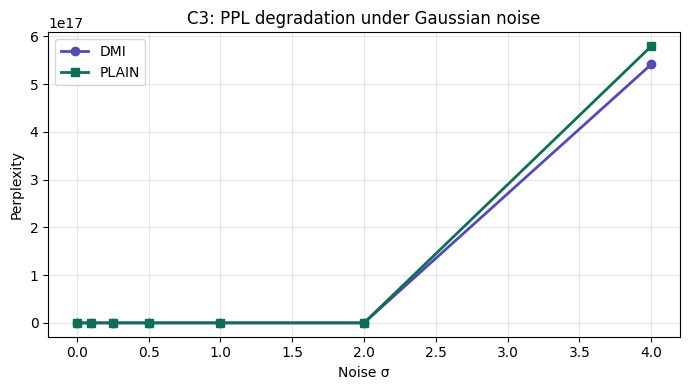

Saved → c3_noise_curve.png


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# C3: Noise degradation curve
# Add Gaussian noise of increasing σ to embeddings, measure PPL.
# Decoder that genuinely relies on the embedding degrades smoothly.
# Decoder that ignores it stays flat (same as the swap test, but graded).
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

@torch.no_grad()
def ppl_at_noise(model, encoder, utterances, sigma, n=300, batch_size=32):
    random.seed(42)
    sample = random.sample(utterances, n)
    toks_list = [
        torch.tensor(
            [tokenizer.cls_token_id]
            + tokenizer.encode(u, add_special_tokens=False,
                               max_length=MAX_TOK_LEN - 2, truncation=True)
            + [tokenizer.sep_token_id])
        for u in sample
    ]
    embs = []
    for i in range(0, n, 256):
        batch  = sample[i:i+256]
        tokens = tokenizer(batch, return_tensors='pt', padding=True,
                           truncation=True, max_length=64).to(device)
        out    = encoder(**tokens).last_hidden_state[:, 0, :].cpu()
        embs.append(out)
    embs = torch.cat(embs, 0)

    # Inject noise
    noisy = embs + sigma * torch.randn_like(embs)

    criterion = nn.CrossEntropyLoss(
        ignore_index=tokenizer.pad_token_id, reduction='mean')
    losses = []
    model.eval()
    for i in range(0, n, batch_size):
        toks = pad_sequence(toks_list[i:i+batch_size], batch_first=True,
                            padding_value=tokenizer.pad_token_id).to(device)
        emb  = noisy[i:i+batch_size].to(device)
        logits = model(toks[:, :-1], emb)
        loss   = criterion(logits.reshape(-1, VOCAB_SIZE),
                           toks[:, 1:].reshape(-1))
        losses.append(loss.item())
    return float(np.exp(np.mean(losses)))

sigmas = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0]
print("=== C3: PPL under Gaussian noise ===\n")
header = f"{'σ':>6}" + "".join(f"{'DMI':>10}{'PLAIN':>10}")
print(f"{'σ':>6}  {'DMI PPL':>10}  {'PLAIN PPL':>10}")
print("─" * 32)

dmi_ppls, plain_ppls = [], []
for s in sigmas:
    p_d = ppl_at_noise(model_dmi,   bert_dmi,   valid_utts, s)
    p_p = ppl_at_noise(model_plain, bert_plain, valid_utts, s)
    dmi_ppls.append(p_d);  plain_ppls.append(p_p)
    print(f"  {s:>4}   {p_d:>10.2f}  {p_p:>10.2f}")

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sigmas, dmi_ppls,   'o-', label='DMI',   color='#534AB7', linewidth=2)
ax.plot(sigmas, plain_ppls, 's-', label='PLAIN', color='#0F6E56', linewidth=2)
ax.set_xlabel('Noise σ'); ax.set_ylabel('Perplexity')
ax.set_title('C3: PPL degradation under Gaussian noise')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'{ckpt_dir}/c3_noise_curve.png', dpi=150); plt.show()
print("Saved → c3_noise_curve.png")

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# C4: Act probe on decoder hidden states
# Hook the decoder's first transformer layer output.
# Train a linear probe to predict discourse act from those states.
# If the decoder is *using* the act signal from the embedding,
# the hidden states will carry act information.
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

hidden_store = {}

def make_hook(key):
    def hook(module, inp, out):
        # out shape: (B, T, D) — take the [CLS] position (pos 0)
        hidden_store[key] = out[:, 0, :].detach().cpu()
    return hook

@torch.no_grad()
def extract_decoder_hidden(model, encoder, utterances, labels, batch_size=64):
    """
    Pass each utterance through the decoder (teacher-forced on its own tokens).
    Capture the first decoder layer's output at position 0.
    """
    handle = model.decoder.layers[0].register_forward_hook(make_hook('layer0'))
    all_h, all_y = [], []
    model.eval()

    for i in range(0, len(utterances), batch_size):
        batch = utterances[i:i+batch_size]
        batch_labels = labels[i:i+batch_size]

        # Encode with BERT
        enc_tokens = tokenizer(batch, return_tensors='pt', padding=True,
                               truncation=True, max_length=64).to(device)
        emb = encoder(**enc_tokens).last_hidden_state[:, 0, :]

        # Tokenise targets
        toks_list = []
        for u in batch:
            t = tokenizer.encode(u, add_special_tokens=False,
                                 max_length=MAX_TOK_LEN - 2, truncation=True)
            toks_list.append(torch.tensor(
                [tokenizer.cls_token_id] + t + [tokenizer.sep_token_id]))
        toks = pad_sequence(toks_list, batch_first=True,
                            padding_value=tokenizer.pad_token_id).to(device)

        _ = model(toks[:, :-1], emb)   # trigger hook
        all_h.append(hidden_store['layer0'].numpy())
        all_y.extend(batch_labels)

    handle.remove()
    return np.vstack(all_h), np.array(all_y)

print("Extracting decoder hidden states (this takes a few minutes)...")
H_dmi,   y_dmi   = extract_decoder_hidden(model_dmi,   bert_dmi,   valid_utts, valid_labels)
H_plain, y_plain = extract_decoder_hidden(model_plain, bert_plain, valid_utts, valid_labels)

# Train-set hidden states for the probe
H_tr_dmi,   y_tr  = extract_decoder_hidden(model_dmi,   bert_dmi,   train_utts[:10000], train_labels[:10000])
H_tr_plain, _     = extract_decoder_hidden(model_plain, bert_plain, train_utts[:10000], train_labels[:10000])

print("\n=== C4: Discourse act probe on decoder layer-1 hidden states ===\n")
print(f"{'Source':<30} {'Probe acc':>10}")
print("─" * 44)
for name, H_tr, H_val, y_tr_lbl, y_val_lbl in [
    ('DMI   dec hidden states', H_tr_dmi,   H_dmi,   y_tr,  np.array(valid_labels)),
    ('PLAIN dec hidden states', H_tr_plain, H_plain, y_tr,  np.array(valid_labels)),
]:
    probe = LogisticRegression(max_iter=500, C=1.0, class_weight='balanced')
    probe.fit(H_tr, y_tr_lbl)
    acc = accuracy_score(y_val_lbl, probe.predict(H_val))
    bar = '█' * int(acc * 40)
    print(f"  {name:<30} {acc:>10.4f}  {bar}")

print(f"\n  Random baseline ≈ 0.25 (4 balanced classes)")
print("  DMI higher → act signal in embedding propagates into decoder states")

Extracting decoder hidden states (this takes a few minutes)...

=== C4: Discourse act probe on decoder layer-1 hidden states ===

Source                          Probe acc
────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  DMI   dec hidden states            0.8350  █████████████████████████████████
  PLAIN dec hidden states            0.8446  █████████████████████████████████

  Random baseline ≈ 0.25 (4 balanced classes)
  DMI higher → act signal in embedding propagates into decoder states


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# C5: Act-conditional steering via centroid interpolation
# Compute the mean embedding per act class from the validation set.
# For a neutral "Inform" utterance, interpolate toward the Question / Directive
# centroid and watch the decoder output shift communicative function.
# ══════════════════════════════════════════════════════════════════════════════

# Build centroids from validation embeddings
print("Computing act centroids...")
X_val_dmi = get_embeddings(bert_dmi, valid_utts)     # (N, 768)
val_labels_arr = np.array(valid_labels)

centroids = {}
for act_id, act_name in ACT_NAMES.items():
    mask = val_labels_arr == act_id
    if mask.sum() > 0:
        centroids[act_id] = X_val_dmi[mask].mean(axis=0)
        print(f"  {act_name}: {mask.sum()} samples")

def steer_decode(model, enc, text, target_centroid, alpha, max_len=40):
    """Decode after moving the embedding α toward a target centroid."""
    emb = encode_with(enc, text).numpy()
    steered = (1 - alpha) * emb + alpha * target_centroid
    steered_t = torch.tensor(steered, dtype=torch.float32).unsqueeze(0).to(device)
    bos, eos = tokenizer.cls_token_id, tokenizer.sep_token_id
    generated = [bos]
    model.eval()
    with torch.no_grad():
        for _ in range(max_len):
            inp      = torch.tensor([generated], device=device)
            logits   = model(inp, steered_t)
            next_tok = logits[0, -1].argmax().item()
            if next_tok == eos:
                break
            generated.append(next_tok)
    return tokenizer.decode(generated[1:], skip_special_tokens=True)

# Test sentences (all Inform class)
steering_tests = [
    "the conference is scheduled for friday afternoon .",
    "the nearest pharmacy is two blocks away .",
    "she has been working at the company for five years .",
    "the package was delivered this morning .",
]

print("\n=== C5: Act-conditional steering ===")
print("(α=0 → original, α=1 → pure centroid)\n")

for src in steering_tests:
    print(f"SOURCE: {src}")
    for act_id, act_name in [(1, 'Question'), (2, 'Commissive'), (3, 'Directive')]:
        if act_id not in centroids:
            continue
        print(f"  → steer toward {act_name}:")
        for alpha in [0.0, 0.3, 0.6, 1.0]:
            out = steer_decode(model_dmi, bert_dmi, src,
                               centroids[act_id], alpha) or "—"
            print(f"      α={alpha:.1f}  {out}")
    print()

# Measure act-shift rate: what fraction of α=0.6 outputs match the target act?
print("=== Act-shift rate at α=0.6 (DMI vs PLAIN) ===\n")
random.seed(42)
inform_utts = [u for u, l in zip(valid_utts, valid_labels) if l == 0]
steer_sample = random.sample(inform_utts, 150)
target_act   = 1   # steer toward Question

X_val_plain = get_embeddings(bert_plain, valid_utts)
centroids_plain = {}
for act_id in ACT_NAMES:
    mask = val_labels_arr == act_id
    if mask.sum() > 0:
        centroids_plain[act_id] = X_val_plain[mask].mean(axis=0)

print(f"{'Encoder':<10} {'Act-shift @ α=0.6':>20}")
print("─" * 34)
for name, model, enc, cents in [
    ('DMI',   model_dmi,   bert_dmi,   centroids),
    ('PLAIN', model_plain, bert_plain, centroids_plain),
]:
    hits = 0
    for utt in tqdm(steer_sample, desc=name):
        out = steer_decode(model, enc, utt, cents[target_act], 0.6) or ""
        if discourse_act_label(out) == target_act:
            hits += 1
    rate = hits / len(steer_sample)
    bar  = '█' * int(rate * 40)
    print(f"  {name:<10} {rate:>20.4f}  {bar}")

print("\nExpected: DMI steering works; PLAIN output unchanged regardless of centroid.")

Computing act centroids...
  Inform: 5018 samples
  Question: 2728 samples
  Commissive: 162 samples
  Directive: 161 samples

=== C5: Act-conditional steering ===
(α=0 → original, α=1 → pure centroid)

SOURCE: the conference is scheduled for friday afternoon .
  → steer toward Question:
      α=0.0  attend the weekend of the evening.
      α=0.3  hear the middle of the campus.
      α=0.6  have an annual attend.


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


      α=1.0  much is that ' ll set?
  → steer toward Commissive:
      α=0.0  attend the weekend of the evening.
      α=0.3  attend the middle of the weekend.
      α=0.6  will be held by the end of this week.
      α=1.0  course. ' s put up with your old voice.
  → steer toward Directive:
      α=0.0  attend the weekend of the evening.
      α=0.3  attend the orientation of five.
      α=0.6  set up by this morning.
      α=1.0  morning. ' ll make a touch with you.

SOURCE: the nearest pharmacy is two blocks away .
  → steer toward Question:
      α=0.0  know the next bus stop is away from town.
      α=0.3  know which one is better by the next stop.
      α=0.6  , it ' s better than five times.
      α=1.0  much is that ' ll set?
  → steer toward Commissive:
      α=0.0  know the next bus stop is away from town.
      α=0.3  , it is better than five minutes ago.
      α=0.6  , it ' s better than five times.
      α=1.0  course. ' s put up with your old voice.
  → steer toward Direct

DMI:   0%|          | 0/150 [00:00<?, ?it/s]

  DMI                      0.7133  ████████████████████████████


PLAIN:   0%|          | 0/150 [00:00<?, ?it/s]

  PLAIN                    0.7333  █████████████████████████████

Expected: DMI steering works; PLAIN output unchanged regardless of centroid.
